# 세 방식 비교 — BERT · T5 · GPT 계열을 같은 데이터, 같은 평가로

**[AI아카데미] A4021 언어지능: 언어모델 기반 자연어처리 실습 기초** · 2일차 보조 노트북

> **파일 이름은 `bert_vs_llm.ipynb` 이지만 내용은 BERT · T5 · GPT 계열 세 방식의 비교입니다.**
> 강의 자료와 실습 안내가 이 파일 이름을 가리키고 있어 이름만 그대로 두었습니다.

이 노트북은 **GPU가 없어도 실행됩니다.** 강사가 미리 돌려 둔 실험 결과(`results/` 폴더의 JSON)를 읽어
표와 그래프로 정리합니다. 아직 돌지 않은 실험이 있으면 그 칸만 비워 두고 나머지를 보여 줍니다.

질문은 하나입니다.

> **같은 한국어 태스크를 세 가지 구조로 풀어 보면 무엇이 달라지는가?**

1일차에는 인코더(BERT)로 라벨과 위치를 골랐고(실습1·2·4A), 인코더-디코더(pko-T5)로 답을 써 봤습니다(실습4B).
2일차에는 디코더(GPT 계열)로 같은 일을 합니다(실습5). 이 노트북은 그 셋을 한 표에 놓습니다.

## 비교 설계 — 무엇을 같게 맞췄나

공정한 비교의 핵심은 **평가셋과 채점 방식을 완전히 같게** 하는 것입니다.

| 항목 | BERT (인코더) | T5 (인코더-디코더) | GPT 계열 (디코더) |
|---|---|---|---|
| 평가셋 | 태스크당 **300건**, 공식 test/validation에서 뽑음 | 같은 300건 (바이트 단위로 동일) | 같은 300건 |
| 채점 | 공식 지표 — `common.py`의 같은 함수 | 같은 함수 | 같은 함수 |
| 학습 — budget | LLM과 **같은 예제 수**(태스크당 600~1,000건), 3에폭 | 같은 예제, 같은 3에폭 | — |
| 학습 — full | 공식 train **전체**, 1에폭 | 같은 전체, 1에폭 | — |
| 학습 — LoRA | — | — | 여섯 태스크를 **한 번에**, 어댑터만(전체의 약 1%) |
| 모델 수 | 태스크마다 하나 | 태스크마다 하나 | 어댑터 **하나**로 전부 |
| 학습셋 ↔ 평가셋 | 겹치는 문장은 학습셋에서 제거 (`build_dataset.py`가 검사) | 같음 | 같음 |

## 여섯 태스크

- **세 방식 모두 가능한 네 태스크** — 주제분류(KLUE-YNAT) · 개체명인식(KLUE-NER) · 기계독해(KorQuAD) · 문장유사도(KLUE-STS)
- **생성 모델만 가능한 두 태스크** — 수학추론(GSM8K-ko) · SQL생성(Spider-ko)

### 뺀 태스크에 대하여

이전 구성에는 감성분류(NSMC)와 자연어추론(KLUE-NLI)도 있었지만 이번 개편에서 뺐습니다.
감성분류는 어느 방식으로 풀어도, 심지어 학습하지 않은 LLM으로도 점수가 높게 나와(상향평준화)
**세 방식의 차이가 드러나지 않았습니다.** 자연어추론은 "전제가 참일 때 가설이 반드시 참인가"라는
개념을 먼저 설명해야 하는데, NLP 배경이 없는 수강생에게는 그 설명 비용이 크고,
두 문장을 함께 읽어 관계를 판단한다는 점에서 문장유사도와 자리가 겹쳤습니다.
둘 중 **문장유사도를 남긴 이유**는 두 가지입니다. (가) "두 문장이 얼마나 비슷한지 0~5점"이라
설명이 거의 필요 없고, (나) 학습 전과 후의 차이가 훨씬 커서 파인튜닝의 효과가 눈에 보입니다.
학습이 끝난 뒤의 점수는 두 태스크가 거의 같지만 출발점이 다릅니다 — **근거는 §7에서 이전 구성 결과로 확인합니다.**

## 0. 준비 — 결과 JSON 읽기

`compare.py`는 `results/` 아래의 JSON을 pandas 표로 바꿔 주는 작은 도우미입니다.
파일 이름 규칙이 코드에 그대로 적혀 있으니 한 번 열어 보세요.

- `results/sweep2/` — 이번 개편의 LLM 스윕 (모델 여러 개 × 여섯 태스크, 학습 전/후)
- `results/t5/` — T5 기준선 (모델 × 태스크 × budget/full)
- `results/bert/` — BERT 기준선 (모델 × 태스크 × budget/full)
- `results/sweep/`, `results/ablation/` — **이전 6태스크 구성**의 결과 (§7에서만 씁니다)

In [1]:
import os, sys
# 이 노트북은 task5-llm-ft/ 폴더 안에서 실행합니다. (결과는 같은 폴더의 results/ 에 있습니다)
if os.path.basename(os.getcwd()) != "task5-llm-ft" and os.path.isdir("task5-llm-ft"):
    os.chdir("task5-llm-ft")
sys.path.insert(0, os.getcwd())
print("작업 폴더:", os.path.basename(os.getcwd()))

import json, re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from compare import (load_sweep, load_bert, load_t5, setup_korean_font,
                     TASK_ORDER, THREE_WAY_TASKS, GEN_ONLY_TASKS,
                     TASK_NAME, TASK_DATA, TASK_LABEL, MAIN_METRIC, METRIC_KO, MODEL_INFO,
                     LINEUP, LINEUP_GROUP, LINEUP_WHY, CONTRASTS)

pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 40)
print("그래프 글꼴:", setup_korean_font())

# 색 약속 — 노트북 전체에서 같은 색을 씁니다.
C_BERT, C_T5, C_BEFORE, C_AFTER = "#4a7fb5", "#4f9d69", "#bbbbbb", "#e07b39"

작업 폴더: task5-llm-ft


그래프 글꼴: ['NanumGothic']


In [2]:
RES = "results"

NUMCOLS = ["before", "after", "delta", "before_sec", "after_sec", "broken_before", "broken_after",
           "n_eval", "train_min", "peak_gpu_gb", "trainable_m", "n_train", "params_b",
           "score", "eval_sec", "epochs", "params_m", "broken_format"]

def ensure(df, cols):
    # 결과가 하나도 없으면 load_*() 가 빈 표를 돌려준다. 그래도 뒤 셀이 죽지 않도록 열을 만들어 둔다.
    df = df.copy() if df is not None else pd.DataFrame()
    for c in cols:
        if c not in df.columns:
            df[c] = pd.Series(dtype="object")
    for c in NUMCOLS:                       # 값이 없는 열이 문자열로 남아 계산을 막지 않게
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    return df

LLM_COLS = ["tag", "model", "org", "kind", "params_b", "task", "task_name", "metric",
            "before", "after", "delta", "before_sec", "after_sec", "broken_before", "broken_after",
            "n_eval", "train_min", "peak_gpu_gb", "trainable_m", "n_train", "loss_mode", "template"]
BASE_COLS = ["model", "short", "task", "task_name", "mode", "metric", "score", "eval_sec",
             "n_eval", "n_train", "epochs", "train_min", "peak_gpu_gb", "params_m"]

llm_all = ensure(load_sweep(RES, sub="sweep2"), LLM_COLS)   # 2026-09 개편 스윕
bert = ensure(load_bert(RES), BASE_COLS)
t5 = ensure(load_t5(RES), BASE_COLS + ["broken_format"])

# 에폭 실험(-2ep, -3ep) · 양자화(-4bit) 같은 변형 tag 는 '모델 비교' 표에서 빼 둔다 (§5에서 따로 본다).
VARIANT = r"-(?:\d+ep|4bit|plain|fullloss)$"
is_variant = llm_all["tag"].astype(str).str.contains(VARIANT, regex=True)
llm = llm_all[~is_variant].copy()

n = lambda df, c="model": int(df[c].nunique()) if len(df) else 0
print(f"LLM {n(llm)}종 · T5 {n(t5)}종 · BERT {n(bert)}종")
print("태스크:", ", ".join(f"{TASK_NAME[t]}({TASK_DATA[t]})" for t in TASK_ORDER))
for name, df in [("sweep2", llm_all), ("t5", t5), ("bert", bert)]:
    if not len(df):
        print(f"  [알림] results/{name}/ 결과가 아직 없습니다 — 그 칸은 비워 둔 채 진행합니다.")
if len(llm) and llm["after"].isna().all():
    print("  [알림] 학습 후 점수가 아직 없습니다 (스윕이 도는 중). 학습 전 점수만 보여 줍니다.")
print("  ※ LLM은 학습이 끝나 train_meta.json 이 생긴 모델부터 표에 나타납니다.")

LLM 16종 · T5 1종 · BERT 5종
태스크: 주제분류(KLUE-YNAT), 개체명인식(KLUE-NER), 기계독해(KorQuAD), 문장유사도(KLUE-STS), SQL생성(Spider-ko), 수학추론(GSM8K-ko)
  ※ LLM은 학습이 끝나 train_meta.json 이 생긴 모델부터 표에 나타납니다.


In [3]:
# --- 표를 만들 때 반복해서 쓰는 작은 도구들 -------------------------------------------
def num(x):
    v = pd.to_numeric(pd.Series([x]), errors="coerce").iloc[0]
    return None if pd.isna(v) else float(v)

def pick_model(df, prefer):
    # prefer 순서대로 있으면 그것을, 없으면 데이터에 있는 첫 모델을 고른다.
    have = list(dict.fromkeys(df["model"].dropna().tolist())) if len(df) else []
    for p in prefer:
        if p in have:
            return p
    return have[0] if have else None

def score_of(df, model, task, mode=None, col="score"):
    # 없는 조합이면 None. 표의 그 칸만 비고 나머지는 그대로 나온다.
    if model is None or not len(df):
        return None
    s = df[(df["model"] == model) & (df["task"] == task)]
    if mode is not None:
        s = s[s["mode"] == mode]
    s = pd.to_numeric(s[col], errors="coerce").dropna()
    return round(float(s.iloc[0]), 1) if len(s) else None

def agg(df, col, how="sum"):
    s = pd.to_numeric(df[col], errors="coerce").dropna() if len(df) else pd.Series(dtype=float)
    if not len(s):
        return None
    return round(float({"sum": s.sum, "max": s.max, "first": lambda: s.iloc[0], "mean": s.mean}[how]()), 1)

def sum1(s):
    # 값이 하나도 없으면 0이 아니라 빈 칸으로 둔다 ("아직 안 쟀다"와 "0초"는 다르다)
    return pd.to_numeric(s, errors="coerce").sum(min_count=1)

def drop_empty(df, axis=0):
    return df.dropna(axis=axis, how="all") if len(df) else df

def pivot_tasks(df, value, tasks, index="model", avg="평균"):
    # (모델 × 태스크) 표. 없는 태스크 열은 그냥 빠진다.
    if not len(df):
        return pd.DataFrame()
    sub = df[df["task"].isin(tasks)]
    if not len(sub) or sub[value].isna().all():
        return pd.DataFrame()
    t = sub.pivot_table(index=index, columns="task", values=value, aggfunc="first")
    t = t.reindex(columns=[c for c in tasks if c in t.columns])
    t.columns = [TASK_NAME[c] for c in t.columns]
    if avg:
        t[avg] = t.mean(axis=1)
    return t.round(1)

def by_size(df):
    # 작은 모델부터 정렬한 모델 이름 목록
    if not len(df):
        return []
    d = df.drop_duplicates("model").copy()
    d["params_b"] = pd.to_numeric(d["params_b"], errors="coerce")
    return d.sort_values("params_b", na_position="last")["model"].tolist()

def bars(ax, labels, vals, colors, hatches=None, fmt="{:.0f}", ymax=105):
    v = [np.nan if x is None else float(x) for x in vals]
    bb = ax.bar(range(len(v)), v, color=colors)
    for i, b in enumerate(bb):
        if hatches:
            b.set_hatch(hatches[i])
        if not np.isnan(v[i]):
            ax.text(b.get_x() + b.get_width() / 2, v[i] + 1, fmt.format(v[i]), ha="center", fontsize=8)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=60, ha="right", fontsize=8)
    ax.set_ylim(0, ymax)
    ax.grid(axis="y", alpha=0.3)

print("도구 준비 완료")

도구 준비 완료


In [4]:
# 각 방식의 '기준 모델' — 세 방식을 1:1로 놓을 때 쓸 대표 하나씩.
BERT_REF = pick_model(bert, ["KLUE-RoBERTa-base", "KLUE-BERT-base", "KLUE-RoBERTa-large", "KLUE-RoBERTa-small"])
T5_REF = pick_model(t5, ["pko-T5-base", "pko-T5-large", "KE-T5-base", "pko-T5-small"])
LLM_REF = pick_model(llm, ["A.X-4.0-Light (7B)", "EXAONE-4.0-1.2B", "kanana-1.5-2.1B-instruct", "Qwen3.5-2B", "Llama-3.2-3B-Instruct"])
print(f"기준 모델 — BERT: {BERT_REF} / T5: {T5_REF} / LLM: {LLM_REF}")
print("(실습1·2에서 쓴 BERT, 실습4B에서 쓴 T5, 실습5의 기본 LLM 입니다. 없으면 있는 것 중 하나를 씁니다.)")

기준 모델 — BERT: KLUE-RoBERTa-base / T5: pko-T5-base / LLM: A.X-4.0-Light (7B)
(실습1·2에서 쓴 BERT, 실습4B에서 쓴 T5, 실습5의 기본 LLM 입니다. 없으면 있는 것 중 하나를 씁니다.)


## 1. 세 방식이 무엇이 다른가

### 구조

**BERT — 인코더.** 문장 전체를 앞뒤로 함께 읽어 토큰마다 벡터를 만듭니다. 그 위에 작은 분류기(head)를 얹어
*정해진 후보 중 하나를 고르거나*(문장 분류), *토큰마다 태그를 붙이거나*(개체명인식),
*지문에서 답이 시작하고 끝나는 위치를 고릅니다*(추출형 QA). 고를 수 있는 것이 미리 정해져 있으므로
**없는 말을 지어낼 수 없습니다.** 대신 정답이 후보 밖에 있으면 아예 손을 못 댑니다.

**T5 — 인코더-디코더.** 인코더가 입력을 읽고, 디코더가 답을 **한 토큰씩 써냅니다.**
출력이 글자이므로 라벨도 쓸 수 있고, 지문에 없는 계산 결과도 쓸 수 있습니다.
태스크는 입력 앞에 붙이는 짧은 표시(prefix)로 구분합니다. 2일차 오전 실습4B의 pko-T5 생성형 QA가 이 방식입니다.

**LLM — 디코더.** 인코더가 따로 없고, 앞말에 이어 다음 토큰을 계속 씁니다.
태스크를 구분하는 것은 구조가 아니라 **지시문**입니다. 그래서 학습을 한 번도 하지 않아도 일단 시켜 볼 수 있고
(학습 전 = zero-shot), 지시문만 바꾸면 다른 일을 합니다.

| | BERT (인코더) | T5 (인코더-디코더) | GPT 계열 (디코더) |
|---|---|---|---|
| 하는 일 | 읽고 **라벨이나 위치를 고른다** | 읽고 **답을 글자로 써낸다** | 앞말에 이어 **계속 써낸다** |
| 출력 | 정해진 후보 중 하나 / 지문 속 구간 | 자유 텍스트 | 자유 텍스트 |
| 없는 말을 지어낼 수 있나 | 구조상 못 한다 | 할 수 있다 | 할 수 있다 |
| 형식이 깨질 수 있나 | 없다 | 있다 (후처리 필요) | 있다 (후처리 필요) |
| 태스크를 바꾸려면 | head를 바꾸고 다시 학습 | prefix를 바꾸고 다시 학습 | **지시문만 바꾼다** |
| 학습 없이 시켜 보기 | 불가능 (head가 비어 있다) | 사실상 불가능 | 가능 (zero-shot) |
| 여러 태스크 | 태스크마다 모델 하나 | 함께 학습 가능 | 어댑터 하나로 함께 |
| 1일차·2일차 실습 | 실습1·2, 실습4A | 실습4B (pko-T5) | 실습5 |

### 규모와 비용

아래 표는 위 설명을 숫자로 바꾼 것입니다. **네 태스크(주제분류·개체명인식·기계독해·문장유사도)** 기준입니다.
BERT와 T5는 태스크마다 모델을 따로 만들어야 하므로 **네 번 학습한 시간의 합**이고,
LLM은 여섯 태스크를 한 번에 학습하므로 **한 번의 학습 시간**입니다.

In [5]:
rows = []
for label, df, ref, fam in [("BERT (인코더)", bert, BERT_REF, "bert"), ("T5 (인코더-디코더)", t5, T5_REF, "t5")]:
    for mode, mlab in [("budget", "같은 예산"), ("full", "전체 train")]:
        s = df[(df["model"] == ref) & (df["mode"] == mode) & (df["task"].isin(THREE_WAY_TASKS))] if ref else df.iloc[0:0]
        rows.append({
            "방식": label, "모델": f"{ref} · {mlab}" if ref else "(결과 없음)",
            "총 파라미터(M)": agg(s, "params_m", "first"),
            "학습하는 파라미터(M)": agg(s, "params_m", "first"),   # 전체 파라미터를 학습한다
            "학습 시간(분)": agg(s, "train_min", "sum"),
            "GPU 메모리(GB)": agg(s, "peak_gpu_gb", "max"),
            "추론 시간(초)": agg(s, "eval_sec", "sum"),
            "만들어지는 모델": f"{len(s)}개" if len(s) else None,
        })

s = llm[llm["model"] == LLM_REF] if LLM_REF else llm.iloc[0:0]
s4 = s[s["task"].isin(THREE_WAY_TASKS)]
rows.append({
    "방식": "GPT 계열 (디코더)", "모델": f"{LLM_REF} · LoRA" if LLM_REF else "(결과 없음)",
    "총 파라미터(M)": (agg(s, "params_b", "first") or 0) * 1000 or None,
    "학습하는 파라미터(M)": agg(s, "trainable_m", "first"),
    "학습 시간(분)": agg(s, "train_min", "first"),
    "GPU 메모리(GB)": agg(s, "peak_gpu_gb", "first"),
    "추론 시간(초)": agg(s4, "after_sec", "sum"),
    "만들어지는 모델": "어댑터 1개" if len(s) else None,
})

overview = pd.DataFrame(rows).set_index("방식")
overview = overview[overview.drop(columns="모델").notna().any(axis=1)]   # 아직 결과가 없는 줄은 뺀다
print("※ 학습 시간·추론 시간은 네 태스크(주제분류·개체명인식·기계독해·문장유사도) 기준.")
print("   추론 시간은 태스크당 300건씩 총 1,200건을 처리한 시간의 합입니다.")
print("   LLM의 학습 시간은 여섯 태스크를 한 번에 학습한 값이라 네 태스크만 학습하면 더 짧습니다.")
overview

※ 학습 시간·추론 시간은 네 태스크(주제분류·개체명인식·기계독해·문장유사도) 기준.
   추론 시간은 태스크당 300건씩 총 1,200건을 처리한 시간의 합입니다.
   LLM의 학습 시간은 여섯 태스크를 한 번에 학습한 값이라 네 태스크만 학습하면 더 짧습니다.


,모델,총 파라미터(M),학습하는 파라미터(M),학습 시간(분),GPU 메모리(GB),추론 시간(초),만들어지는 모델
방식,,,,,,,
BERT (인코더),KLUE-RoBERTa-base · 같은 예산,110.0,110.0,0.4,6.2,0.7,4개
BERT (인코더),KLUE-RoBERTa-base · 전체 train,110.0,110.0,7.4,6.2,0.8,4개
T5 (인코더-디코더),pko-T5-base · 같은 예산,275.6,275.6,7.9,14.6,130.1,4개
T5 (인코더-디코더),pko-T5-base · 전체 train,275.6,275.6,90.8,42.9,75.1,4개
GPT 계열 (디코더),A.X-4.0-Light (7B) · LoRA,7300.0,40.4,19.7,17.1,104.2,어댑터 1개


**읽는 법**

- **크기가 다릅니다.** BERT·T5는 억 단위, LLM은 십억 단위입니다. 다만 LLM은 LoRA로 **전체의 1% 남짓만** 학습합니다.
  "학습하는 파라미터"만 보면 오히려 LLM 쪽이 작습니다.
- **만들어지는 결과물이 다릅니다.** BERT·T5는 태스크 수만큼 모델 파일이 생기고, LLM은 어댑터 파일 하나입니다.
  태스크가 늘어날수록 이 차이가 커집니다.
- **추론 시간이 다릅니다.** BERT는 문장을 한 번 읽고 끝나지만, T5와 LLM은 답을 한 토큰씩 만들어야 합니다.
  같은 1,200건을 처리하는 데 걸리는 시간을 표에서 비교해 보세요. 서비스에서는 이 값이 곧 비용입니다.

### 1-1. LLM 라인업 — 왜 이 아홉 모델인가

1일차 강의에서 소개한 모델 계열 가운데 **서로 구별되는 것만** 골랐습니다. 많이 돌리는 것이 목적이 아니라,
*"강의에서 들은 저 모델이 한국어 태스크를 학습시키면 이 정도 하는구나"* 를 한 표에서 읽게 하는 것이 목적입니다.
묶음은 둘입니다 — **한국어 특화**(국내 기관이 한국어를 주 언어로 만든 것)와 **글로벌**(다국어 범용).
그 안에 짝을 셋 심어 두었습니다: *Base ↔ Instruct*(kanana), *원본 ↔ 한국어 추가학습*(Llama ↔ Bllossom), *1.2B ↔ 20B*(EXAONE ↔ gpt-oss).

In [6]:
rows = []
for tag in LINEUP:
    info = MODEL_INFO[tag]
    s = llm[llm["tag"] == tag]
    rows.append({"묶음": LINEUP_GROUP[tag], "모델": info["name"], "만든 곳": info["org"], "종류": info["kind"],
                 "파라미터(B)": s["params_b"].iloc[0] if len(s) else info["size_b"],
                 "학습 전 평균(6)": round(s["before"].mean(), 1) if len(s) and s["before"].notna().any() else None,
                 "학습 후 평균(6)": round(s["after"].mean(), 1) if len(s) and s["after"].notna().all() else None,
                 "학습(분)": s["train_min"].iloc[0] if len(s) else None,
                 "왜 이 모델인가": LINEUP_WHY[tag].replace("**", "")})
lineup = pd.DataFrame(rows).set_index(["묶음", "모델"])
with pd.option_context("display.max_colwidth", 120):
    display(lineup.astype(object).where(lineup.notna(), "아직 없음"))

만든 곳        종류 파라미터(B) 학습 전 평균(6) 학습 후 평균(6) 학습(분)                                                                                          왜 이 모델인가
묶음     모델                                                                                                                                                                               
한국어 특화 A.X-4.0-Light (7B)            SKT  Instruct     7.3       52.0       69.7  19.7  SKT. 수업에서 직접 학습하는 모델 — 강의장 GPU(24GB)에 들어가는 크기 중 위쪽이고, 파인튜닝 뒤에도 수학추론이 떨어지지 않는다 (학습 20분, GPU 17GB)
       EXAONE-4.0-1.2B                LG  Instruct    1.29       28.3       57.1   9.9                                          국내 대표 소형 모델. 라인업에서 가장 작다 — 크기 축의 아래쪽 (학습 10분, GPU 4.3GB)
       kanana-1.5-2.1B-base        Kakao      Base    2.11       18.9       68.6  15.4                            kanana-instruct와 같은 몸, 후학습만 없는 Base — 지시 따르기를 안 배운 모델이 파인튜닝 뒤 얼마나 따라오나
       kanana-1.5-2.1B-instruct    Kakao  Instruct    2.11       41.3       64.2  24.4                                                     카카오. 같은 크기대(2B)에서 EXAONE·Qwen과 견주는 두 번째 국내 모델
       Bllossom-3B (한국어 추가학습)      서울과기대  Instruct    3.24       30.6       56.9  32.4                            Llama-3.2-3B에 한국어를 추가학습한 모델 — 바로 아래 원본 Llama와 짝을 이뤄 '한국어 추가학습의 효과'를 본다
글로벌    Qwen3.5-4B                Alibaba  Instruct    4.24       57.3       73.9  40.9                                  같은 계열의 4B — 라인업에서 파인튜닝 뒤 평균이 가장 높다. 다만 학습이 45분 걸려 수업 기본 모델로는 무겁다
       Qwen3.5-2B                Alibaba  Instruct     1.9       35.8       66.0  34.8                                            오픈웨이트 성능 선두 계열(Alibaba). 글로벌 모델이 한국어 태스크에서 어디까지 오나의 기준
       Llama-3.2-3B-Instruct        Meta  Instruct    3.24       26.6       57.1  15.9                                                        Meta의 대표 소형 모델이자 Bllossom의 원본. 한국어 학습 전 상태
       Gemma-4-E2B-it             Google  Instruct    5.14       53.7       67.3  31.5                                Google. 파라미터 5.1B이지만 임베딩을 빼면 2B급으로 동작(E2B) — 크기 표기를 그대로 믿으면 안 되는 예
       Ministral-3-3B-Instruct   Mistral  Instruct    3.87       40.2       65.3  22.2                                                                    Mistral(유럽). 미국·중국·한국 밖의 대표 계열
       gpt-oss-20B (MoE)          OpenAI  Instruct   20.94       51.7       72.3  48.3                         OpenAI의 오픈웨이트 MoE 20B — 크기 축의 끝. 21B 중 3.6B만 토큰마다 켜진다. 학습에는 A6000 한 장이 한계

In [7]:
# 묶음별 평균 — 세 방식 공통 네 태스크, 학습 전·후가 모두 있는 모델만
done = llm[llm["tag"].isin(LINEUP)].dropna(subset=["before", "after"])
if len(done):
    g = (done[done["task"].isin(THREE_WAY_TASKS)].assign(묶음=lambda d: d["tag"].map(LINEUP_GROUP))
           .groupby(["묶음", "task_name"])[["before", "after"]].mean().round(1)
           .rename(columns={"before": "학습 전", "after": "학습 후"}).unstack("묶음"))
    g = g.reindex([TASK_NAME[t] for t in THREE_WAY_TASKS])
    print("묶음별 태스크 평균 — 모델 수:", {k: int(v) for k, v in done.groupby(done["tag"].map(LINEUP_GROUP))["tag"].nunique().items()})
    display(g)
else:
    print("학습 전·후가 모두 있는 모델이 아직 없습니다.")

묶음별 태스크 평균 — 모델 수: {'글로벌': 6, '한국어 특화': 5}


학습 전         학습 후       
묶음          글로벌 한국어 특화   글로벌 한국어 특화
task_name                          
주제분류       47.9   43.9  77.8   78.7
개체명인식      28.8   19.0  75.2   68.9
기계독해       60.3   56.8  80.8   80.5
문장유사도      61.0   35.2  82.9   81.6

In [8]:
# 짝지어 읽는 대조 — 두 모델의 학습 전 → 후를 태스크별로 나란히
for label, a, b, what in CONTRASTS:
    da, db = llm[llm["tag"] == a], llm[llm["tag"] == b]
    print(f"\n[{label}] {what}")
    if da.empty or db.empty:
        print("   아직 결과 없음:", " ".join(t for t, d in [(a, da), (b, db)] if d.empty)); continue
    t = pd.DataFrame({
        MODEL_INFO[a]["name"]: [f"{x:.1f} → {y:.1f}" if pd.notna(y) else f"{x:.1f} → —"
                                for x, y in zip(da.set_index("task").reindex(TASK_ORDER)["before"],
                                                da.set_index("task").reindex(TASK_ORDER)["after"])],
        MODEL_INFO[b]["name"]: [f"{x:.1f} → {y:.1f}" if pd.notna(y) else f"{x:.1f} → —"
                                for x, y in zip(db.set_index("task").reindex(TASK_ORDER)["before"],
                                                db.set_index("task").reindex(TASK_ORDER)["after"])],
    }, index=[TASK_NAME[x] for x in TASK_ORDER])
    t.loc["평균(6)"] = [f"{da['before'].mean():.1f} → {da['after'].mean():.1f}" if da["after"].notna().all() else f"{da['before'].mean():.1f} → —",
                        f"{db['before'].mean():.1f} → {db['after'].mean():.1f}" if db["after"].notna().all() else f"{db['before'].mean():.1f} → —"]
    display(t)


[한국어 추가학습] 같은 Llama-3.2-3B 몸에 한국어 데이터를 더 학습시킨 것(Bllossom)이 원본과 어떻게 다른가


,Llama-3.2-3B-Instruct,Bllossom-3B (한국어 추가학습)
주제분류,38.7 → 75.7,45.3 → 76.7
개체명인식,0.2 → 62.1,10.4 → 60.9
기계독해,66.7 → 75.3,60.7 → 75.0
문장유사도,0.5 → 63.8,7.7 → 67.8
SQL생성,19.3 → 27.7,22.0 → 25.7
수학추론,34.3 → 38.3,37.7 → 35.3
평균(6),26.6 → 57.1,30.6 → 56.9



[Base ↔ Instruct] 같은 kanana 2.1B에서 후학습(지시 따르기)이 있고 없고의 차이 — 파인튜닝 전과 후에 각각


,kanana-1.5-2.1B-base,kanana-1.5-2.1B-instruct
주제분류,27.3 → 82.3,47.0 → 80.3
개체명인식,0.2 → 81.9,27.5 → 68.6
기계독해,66.0 → 85.0,44.7 → 80.0
문장유사도,12.0 → 86.7,63.2 → 84.9
SQL생성,6.7 → 39.3,12.0 → 30.3
수학추론,1.0 → 36.3,53.7 → 41.0
평균(6),18.9 → 68.6,41.3 → 64.2



[1.2B ↔ 20B] 가장 작은 모델과 가장 큰 모델 — 크기가 17배면 점수도 그만큼 오르나


,EXAONE-4.0-1.2B,gpt-oss-20B (MoE)
주제분류,40.7 → 71.7,46.0 → 75.3
개체명인식,12.9 → 60.8,37.6 → 80.9
기계독해,51.3 → 75.3,51.7 → 81.7
문장유사도,13.7 → 80.8,81.8 → 88.0
SQL생성,6.3 → 22.3,22.7 → 46.0
수학추론,44.7 → 32.0,70.7 → 62.0
평균(6),28.3 → 57.1,51.7 → 72.3



[1.2B ↔ 7.3B] 수업 모델을 6배로 키우면 무엇이 달라지나 — 특히 파인튜닝 뒤 수학추론


,EXAONE-4.0-1.2B,A.X-4.0-Light (7B)
주제분류,40.7 → 71.7,59.3 → 82.7
개체명인식,12.9 → 60.8,44.0 → 72.2
기계독해,51.3 → 75.3,61.3 → 87.0
문장유사도,13.7 → 80.8,79.3 → 87.7
SQL생성,6.3 → 22.3,17.0 → 35.3
수학추론,44.7 → 32.0,51.0 → 53.3
평균(6),28.3 → 57.1,52.0 → 69.7


**읽는 법**

- **한국어 특화 ↔ 글로벌.** 학습 *전*(zero-shot)에는 한국어 특화 모델이 앞서는 태스크가 있지만,
  같은 데이터로 파인튜닝한 *뒤*에는 두 묶음의 평균이 가까워집니다. 태스크 형식을 배우는 데는 한국어를 얼마나 봤느냐보다
  몸(사전학습 규모·최신성)이 더 크게 작용합니다. 어느 태스크에서 차이가 남는지 표에서 확인하세요.
- **원본 ↔ 한국어 추가학습(Llama ↔ Bllossom).** 추가학습은 *출발점*을 올려 줍니다. 파인튜닝 뒤에도 그 차이가 남는지 보세요 —
  남지 않는다면, 우리 태스크에 필요한 것은 한국어 지식이 아니라 형식이었다는 뜻입니다.
- **Base ↔ Instruct(kanana).** Base는 지시를 따르는 법을 배운 적이 없어 학습 전 점수가 바닥입니다.
  파인튜닝 뒤 Instruct에 얼마나 가까워지는지가 "우리가 가르친 것이 무엇인가"의 답입니다.
- **크기(1.2B ↔ 20B).** 17배 큰 모델이 17배 잘하지는 않습니다. 어느 태스크에서 크기가 값을 하는지 — 대체로 수학추론·SQL생성처럼
  *능력*이 필요한 쪽입니다 — 를 보세요. 학습 비용(시간·메모리) 차이는 §6에 있습니다.

## 2. 네 태스크 정면 비교 — 세 방식이 모두 가능한 문제

주제분류 · 개체명인식 · 기계독해 · 문장유사도. 이 넷은 정답이 **라벨이거나 지문 속 구간**이라
인코더로도 풀 수 있고, 글자로 써낼 수도 있습니다. 그래서 세 방식을 정면으로 겨루게 할 수 있습니다.

여섯 칸을 나란히 놓습니다.

- **BERT 예산 / BERT 전체** — 같은 예제 수로 학습 / 공식 train 전체로 학습
- **T5 예산 / T5 전체** — 같은 규칙
- **LLM 학습 전 / 학습 후** — 지시문만 주고 시킨 결과 / LoRA로 학습한 뒤

먼저 LLM 쪽 전체 모델의 점수부터 봅니다.

In [9]:
order = by_size(llm)
def llm_pivot(value, tasks, avg="평균"):
    t = pivot_tasks(llm, value, tasks, avg=avg)
    return drop_empty(t.reindex(order)) if len(t) else t

before4, after4 = llm_pivot("before", THREE_WAY_TASKS), llm_pivot("after", THREE_WAY_TASKS)
if len(before4):
    print("=== LLM 학습 전 (지시문만, zero-shot) ==="); display(before4)
if len(after4):
    print("=== LLM 학습 후 (LoRA) ==="); display(after4)
    print("=== 변화 (%p) ==="); display((after4 - before4).round(1))
if not len(before4) and not len(after4):
    print("LLM 결과(results/sweep2/)가 아직 없습니다.")
elif not len(after4):
    print("학습 후 점수는 아직 없습니다.")

=== LLM 학습 전 (지시문만, zero-shot) ===


,주제분류,개체명인식,기계독해,문장유사도,평균
model,,,,,
EXAONE-4.0-1.2B,40.7,12.9,51.3,13.7,29.6
Qwen3.5-2B,38.7,20.1,67.3,57.6,45.9
kanana-1.5-2.1B-base,27.3,0.2,66.0,12.0,26.4
kanana-1.5-2.1B-instruct,47.0,27.5,44.7,63.2,45.6
kanana2-3b,55.0,19.7,38.0,42.0,38.7
Bllossom-3B (한국어 추가학습),45.3,10.4,60.7,7.7,31.0
Llama-3.2-3B-Instruct,38.7,0.2,66.7,0.5,26.5
Ministral-3-3B-Instruct,44.3,24.7,45.0,61.0,43.7
Qwen3.5-4B,61.3,42.9,74.0,83.1,65.4


=== LLM 학습 후 (LoRA) ===


,주제분류,개체명인식,기계독해,문장유사도,평균
model,,,,,
EXAONE-4.0-1.2B,71.7,60.8,75.3,80.8,72.1
Qwen3.5-2B,80.7,77.2,80.7,87.4,81.5
kanana-1.5-2.1B-base,82.3,81.9,85.0,86.7,84.0
kanana-1.5-2.1B-instruct,80.3,68.6,80.0,84.9,78.5
kanana2-3b,80.0,78.9,83.0,86.0,82.0
Bllossom-3B (한국어 추가학습),76.7,60.9,75.0,67.8,70.1
Llama-3.2-3B-Instruct,75.7,62.1,75.3,63.8,69.2
Ministral-3-3B-Instruct,76.0,74.4,82.7,80.8,78.5
Qwen3.5-4B,81.3,81.1,86.0,90.8,84.8


=== 변화 (%p) ===


,주제분류,개체명인식,기계독해,문장유사도,평균
model,,,,,
EXAONE-4.0-1.2B,31.0,47.9,24.0,67.1,42.5
Qwen3.5-2B,42.0,57.1,13.4,29.8,35.6
kanana-1.5-2.1B-base,55.0,81.7,19.0,74.7,57.6
kanana-1.5-2.1B-instruct,33.3,41.1,35.3,21.7,32.9
kanana2-3b,25.0,59.2,45.0,44.0,43.3
Bllossom-3B (한국어 추가학습),31.4,50.5,14.3,60.1,39.1
Llama-3.2-3B-Instruct,37.0,61.9,8.6,63.3,42.7
Ministral-3-3B-Instruct,31.7,49.7,37.7,19.8,34.8
Qwen3.5-4B,20.0,38.2,12.0,7.7,19.4


In [10]:
# 세 방식 한 표 — 행은 태스크, 열은 여섯 칸
rows = []
for task in THREE_WAY_TASKS:
    r = {"태스크": f"{TASK_NAME[task]} ({TASK_DATA[task]})", "지표": METRIC_KO[MAIN_METRIC[task]]}
    r["BERT 예산"] = score_of(bert, BERT_REF, task, "budget")
    r["BERT 전체"] = score_of(bert, BERT_REF, task, "full")
    r["T5 예산"] = score_of(t5, T5_REF, task, "budget")
    r["T5 전체"] = score_of(t5, T5_REF, task, "full")
    r["LLM 학습 전"] = score_of(llm, LLM_REF, task, None, "before")
    r["LLM 학습 후"] = score_of(llm, LLM_REF, task, None, "after")
    rows.append(r)
head2head = pd.DataFrame(rows).set_index("태스크")
print(f"BERT={BERT_REF} · T5={T5_REF} · LLM={LLM_REF}   (평가 300건, 공식 지표 %)")
head2head

BERT=KLUE-RoBERTa-base · T5=pko-T5-base · LLM=A.X-4.0-Light (7B)   (평가 300건, 공식 지표 %)


,지표,BERT 예산,BERT 전체,T5 예산,T5 전체,LLM 학습 전,LLM 학습 후
태스크,,,,,,,
주제분류 (KLUE-YNAT),정확도,79.7,84.7,80.7,85.3,59.3,82.7
개체명인식 (KLUE-NER),F1,79.1,86.6,75.0,78.0,44.0,72.2
기계독해 (KorQuAD),EM,75.7,85.0,73.0,84.0,61.3,87.0
문장유사도 (KLUE-STS),피어슨 상관,70.2,90.2,61.5,87.7,79.3,87.7


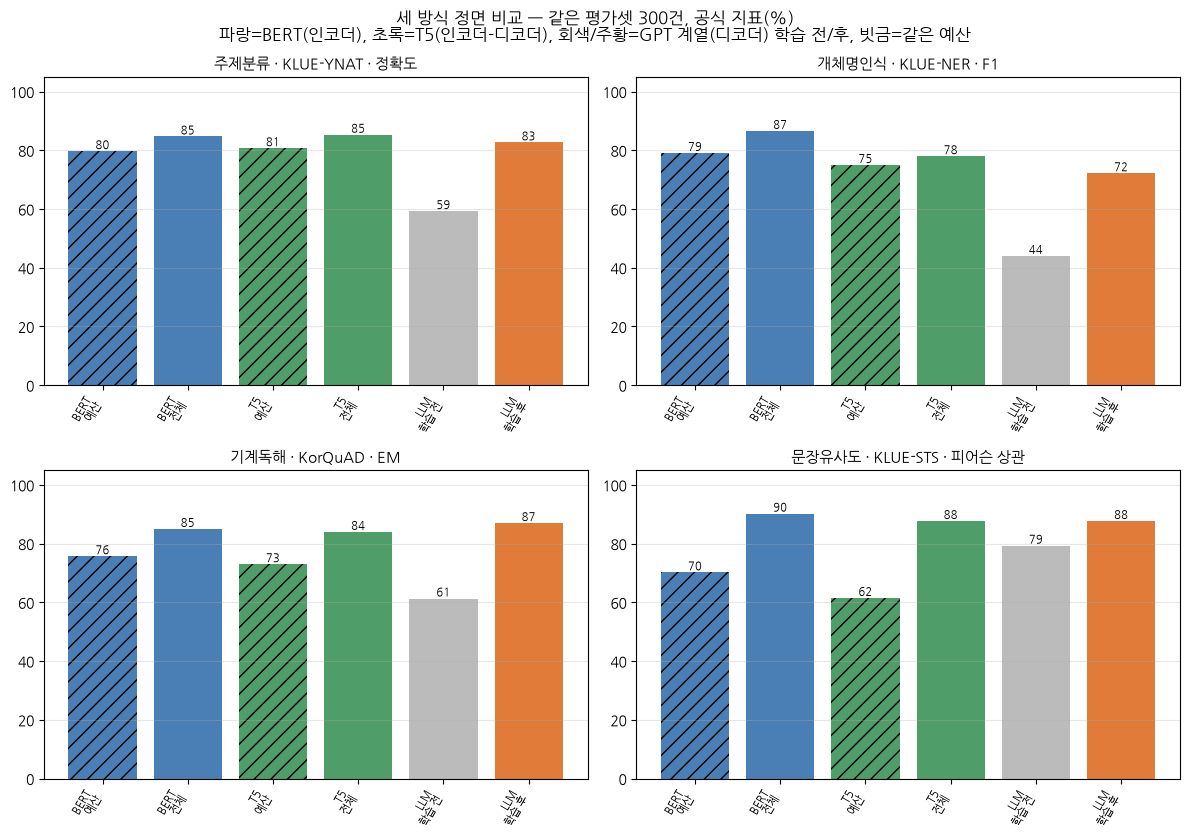

In [11]:
SIX = [("BERT\n예산", C_BERT, "//"), ("BERT\n전체", C_BERT, ""),
       ("T5\n예산", C_T5, "//"), ("T5\n전체", C_T5, ""),
       ("LLM\n학습 전", C_BEFORE, ""), ("LLM\n학습 후", C_AFTER, "")]

fig, axes = plt.subplots(2, 2, figsize=(12, 8.5))
for ax, task in zip(axes.flat, THREE_WAY_TASKS):
    vals = [score_of(bert, BERT_REF, task, "budget"), score_of(bert, BERT_REF, task, "full"),
            score_of(t5, T5_REF, task, "budget"), score_of(t5, T5_REF, task, "full"),
            score_of(llm, LLM_REF, task, None, "before"), score_of(llm, LLM_REF, task, None, "after")]
    bars(ax, [s[0] for s in SIX], vals, [s[1] for s in SIX], [s[2] for s in SIX])
    ax.set_title(TASK_LABEL[task].replace("\n", " · "), fontsize=11)
fig.suptitle("세 방식 정면 비교 — 같은 평가셋 300건, 공식 지표(%)\n"
             "파랑=BERT(인코더), 초록=T5(인코더-디코더), 회색/주황=GPT 계열(디코더) 학습 전/후, 빗금=같은 예산", fontsize=12)
plt.tight_layout(); plt.show()

In [12]:
# 표가 실제로 무엇을 말하는지 자동으로 요약한다 (수치는 전부 위 표에서 온 값이다)
for task in THREE_WAY_TASKS:
    cand = {"BERT 예산": score_of(bert, BERT_REF, task, "budget"),
            "BERT 전체": score_of(bert, BERT_REF, task, "full"),
            "T5 예산": score_of(t5, T5_REF, task, "budget"),
            "T5 전체": score_of(t5, T5_REF, task, "full"),
            "LLM 학습 후": score_of(llm, LLM_REF, task, None, "after")}
    cand = {k: v for k, v in cand.items() if v is not None}
    if not cand:
        print(f"{TASK_NAME[task]}: 아직 결과가 없습니다."); continue
    best = max(cand, key=cand.get)
    zero = score_of(llm, LLM_REF, task, None, "before")
    zs = f" / LLM 학습 전 = {zero}" if zero is not None else ""
    print(f"{TASK_NAME[task]}: 가장 높은 칸 = {best} ({cand[best]}){zs}")

주제분류: 가장 높은 칸 = T5 전체 (85.3) / LLM 학습 전 = 59.3
개체명인식: 가장 높은 칸 = BERT 전체 (86.6) / LLM 학습 전 = 44.0
기계독해: 가장 높은 칸 = LLM 학습 후 (87.0) / LLM 학습 전 = 61.3
문장유사도: 가장 높은 칸 = BERT 전체 (90.2) / LLM 학습 전 = 79.3


**읽는 법 — 무엇을 보아야 하나**

1. **같은 예산끼리(빗금 칸과 LLM 학습 후) 먼저 비교하세요.** 라벨 데이터가 몇백 건뿐인 상황을 흉내 낸 것입니다.
   현장에서 새 태스크를 시작할 때가 대개 이 상황입니다.
2. **전체 train으로 학습한 BERT(빗금 없는 파란 칸)는 "제대로 준비했을 때의 인코더"입니다.**
   데이터가 충분하다면 이 칸을 넘기는 일이 쉽지 않습니다 — 특히 개체명인식처럼
   토큰마다 라벨을 붙이는 구조가 문제에 딱 맞는 경우가 그렇습니다.
3. **LLM의 "학습 전" 칸은 BERT에는 존재하지 않는 칸입니다.** BERT는 head를 학습하기 전에는 아무것도 못 합니다.
   LLM은 데이터 0건에서 시작할 수 있다는 점 자체가 다른 종류의 장점입니다.
4. **T5는 두 방식 사이에 있습니다.** 인코더로 읽지만 답은 글자로 씁니다.
   그래서 형식이 깨질 수 있고(아래 `broken_format`), 대신 다음 절의 두 태스크를 풀 수 있습니다.

In [13]:
# 형식 깨짐 — 생성 방식에만 있는 비용. 채점기가 답을 읽어내지 못한 건수(300건 중)
fmt = []
if len(t5):
    for mode in ["budget", "full"]:
        s = t5[(t5["model"] == T5_REF) & (t5["mode"] == mode)]
        fmt.append(pd.Series({TASK_NAME[r["task"]]: r["broken_format"] for _, r in s.iterrows()},
                             name=f"T5 {T5_REF} ({mode})"))
if len(llm):
    s = llm[llm["model"] == LLM_REF]
    for col, lab in [("broken_before", "학습 전"), ("broken_after", "학습 후")]:
        fmt.append(pd.Series({TASK_NAME[r["task"]]: r[col] for _, r in s.iterrows()}, name=f"LLM {LLM_REF} ({lab})"))
if fmt:
    tbl = pd.DataFrame(fmt).reindex(columns=[TASK_NAME[t] for t in TASK_ORDER])
    tbl = drop_empty(drop_empty(tbl), axis=1)
if fmt and len(tbl):
    print("형식 깨짐 건수 (평가 300건 중) — BERT는 구조상 항상 0입니다.")
    print("(기계독해는 채점이 정답과의 글자 일치라서 '형식 깨짐'을 따로 세지 않습니다.)")
    display(tbl)
else:
    print("생성 방식 결과가 아직 없습니다.")

형식 깨짐 건수 (평가 300건 중) — BERT는 구조상 항상 0입니다.
(기계독해는 채점이 정답과의 글자 일치라서 '형식 깨짐'을 따로 세지 않습니다.)


,주제분류,개체명인식,문장유사도,SQL생성,수학추론
T5 pko-T5-base (budget),0.0,13.0,0.0,0.0,8.0
T5 pko-T5-base (full),0.0,21.0,0.0,0.0,15.0
LLM A.X-4.0-Light (7B) (학습 전),10.0,2.0,0.0,0.0,33.0
LLM A.X-4.0-Light (7B) (학습 후),5.0,1.0,0.0,0.0,8.0


## 3. 생성 모델만 되는 두 태스크 — 수학추론 · SQL생성

### BERT로는 왜 안 되나

BERT는 **고를 수 있는 것 중에서 고릅니다.** 문장 분류라면 라벨 목록에서, 추출형 QA라면 지문 속 위치에서 고릅니다.
그런데 수학추론(GSM8K-ko)의 정답은 계산 결과인 숫자입니다. 문제에 "42"라고 적혀 있지 않으므로
지문에서 고를 수 없고, 가능한 숫자를 모두 라벨로 만들 수도 없습니다. SQL생성(Spider-ko)도 마찬가지로,
정답은 스키마의 표·열 이름을 조합해 **새로 지어낸 문장**입니다. 후보 목록이 존재하지 않습니다.

즉 이 두 태스크에서 BERT 칸이 비어 있는 것은 성능이 나빠서가 아니라 **구조상 시도할 수 없어서**입니다.
"없는 말을 지어내지 못한다"는 §1의 안전장치가 여기서는 한계가 됩니다.
T5와 LLM은 답을 글자로 쓰므로 둘 다 시도할 수 있습니다.

In [14]:
rows = []
for task in GEN_ONLY_TASKS:
    r = {"태스크": f"{TASK_NAME[task]} ({TASK_DATA[task]})", "지표": METRIC_KO[MAIN_METRIC[task]],
         "BERT": "구조상 불가"}
    r["T5 예산"] = score_of(t5, T5_REF, task, "budget")
    r["T5 전체"] = score_of(t5, T5_REF, task, "full")
    r["LLM 학습 전"] = score_of(llm, LLM_REF, task, None, "before")
    r["LLM 학습 후"] = score_of(llm, LLM_REF, task, None, "after")
    rows.append(r)
gen_tbl = pd.DataFrame(rows).set_index("태스크")
gen_tbl

,지표,BERT,T5 예산,T5 전체,LLM 학습 전,LLM 학습 후
태스크,,,,,,
SQL생성 (Spider-ko),EM,구조상 불가,0.3,8.3,17.0,35.3
수학추론 (GSM8K-ko),EM,구조상 불가,1.3,2.0,51.0,53.3


In [15]:
# 모델을 하나만 보면 오해하기 쉬우므로, 두 태스크는 LLM 전체 모델을 함께 봅니다.
gb = llm_pivot("before", GEN_ONLY_TASKS, avg=None)
ga = llm_pivot("after", GEN_ONLY_TASKS, avg=None)
parts = ([gb.add_suffix(" 학습 전")] if len(gb) else []) + ([ga.add_suffix(" 학습 후")] if len(ga) else [])
if parts:
    both = pd.concat(parts, axis=1)
    display(both[sorted(both.columns)])
else:
    print("LLM 결과가 아직 없습니다.")

,SQL생성 학습 전,SQL생성 학습 후,수학추론 학습 전,수학추론 학습 후
model,,,,
EXAONE-4.0-1.2B,6.3,22.3,44.7,32.0
Qwen3.5-2B,13.3,35.0,17.7,35.0
kanana-1.5-2.1B-base,6.7,39.3,1.0,36.3
kanana-1.5-2.1B-instruct,12.0,30.3,53.7,41.0
kanana2-3b,16.7,35.7,36.3,36.7
Bllossom-3B (한국어 추가학습),22.0,25.7,37.7,35.3
Llama-3.2-3B-Instruct,19.3,27.7,34.3,38.3
Ministral-3-3B-Instruct,10.7,35.3,55.7,42.3
Qwen3.5-4B,21.3,45.0,61.3,59.3


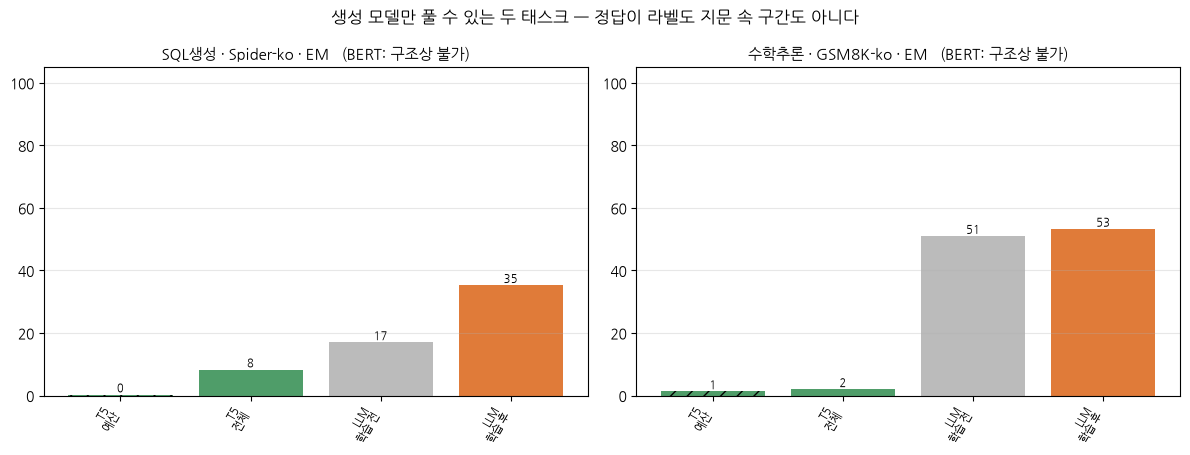

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
FOUR = [("T5\n예산", C_T5, "//"), ("T5\n전체", C_T5, ""),
        ("LLM\n학습 전", C_BEFORE, ""), ("LLM\n학습 후", C_AFTER, "")]
for ax, task in zip(axes, GEN_ONLY_TASKS):
    vals = [score_of(t5, T5_REF, task, "budget"), score_of(t5, T5_REF, task, "full"),
            score_of(llm, LLM_REF, task, None, "before"), score_of(llm, LLM_REF, task, None, "after")]
    bars(ax, [s[0] for s in FOUR], vals, [s[1] for s in FOUR], [s[2] for s in FOUR])
    ax.set_title(TASK_LABEL[task].replace("\n", " · ") + "   (BERT: 구조상 불가)", fontsize=11)
fig.suptitle("생성 모델만 풀 수 있는 두 태스크 — 정답이 라벨도 지문 속 구간도 아니다", fontsize=12)
plt.tight_layout(); plt.show()

**읽는 법**

- 두 태스크는 **점수 자체가 낮게 나오는 것이 정상입니다.** 채점이 EM(정답과 글자까지 완전히 같아야 정답)이고,
  수학추론은 계산을 끝까지 맞혀야, SQL생성은 문법과 표·열 이름을 모두 맞혀야 점수를 받습니다.
- **T5와 LLM의 차이를 보세요.** 소형 T5는 "형식은 흉내 내지만 계산은 못 하는" 상태에 머무르기 쉽습니다.
  같은 크기라도 디코더 LLM은 사전학습에서 훨씬 많은 문장을 봤고, 풀이 과정을 이어 쓰는 연습이 되어 있습니다.
- 이 두 태스크가 **§4에서 "파인튜닝이 못 가르치는 것"의 증거**가 됩니다.
  형식은 몇백 건이면 배우지만, 계산 능력은 그렇게 생기지 않습니다.

## 4. 파인튜닝이 잘 가르치는 것과 못 가르치는 것

같은 학습을 받았는데 태스크마다 오르는 폭이 다릅니다. 그 차이가 파인튜닝의 성격을 말해 줍니다.
아래 셀들은 **여섯 태스크 전부**에 대해 학습 전 → 학습 후의 변화를 봅니다.

In [17]:
d_before, d_after = llm_pivot("before", TASK_ORDER), llm_pivot("after", TASK_ORDER)
if len(d_before):
    print("=== 학습 전 (여섯 태스크) ==="); display(d_before)
if len(d_after):
    print("=== 학습 후 (여섯 태스크) ==="); display(d_after)
    print("=== 상승폭 (학습 후 − 학습 전, %p) ==="); display((d_after - d_before).round(1))
if not len(d_before) and not len(d_after):
    print("LLM 결과가 아직 없습니다.")

=== 학습 전 (여섯 태스크) ===


,주제분류,개체명인식,기계독해,문장유사도,SQL생성,수학추론,평균
model,,,,,,,
EXAONE-4.0-1.2B,40.7,12.9,51.3,13.7,6.3,44.7,28.3
Qwen3.5-2B,38.7,20.1,67.3,57.6,13.3,17.7,35.8
kanana-1.5-2.1B-base,27.3,0.2,66.0,12.0,6.7,1.0,18.9
kanana-1.5-2.1B-instruct,47.0,27.5,44.7,63.2,12.0,53.7,41.3
kanana2-3b,55.0,19.7,38.0,42.0,16.7,36.3,34.6
Bllossom-3B (한국어 추가학습),45.3,10.4,60.7,7.7,22.0,37.7,30.6
Llama-3.2-3B-Instruct,38.7,0.2,66.7,0.5,19.3,34.3,26.6
Ministral-3-3B-Instruct,44.3,24.7,45.0,61.0,10.7,55.7,40.2
Qwen3.5-4B,61.3,42.9,74.0,83.1,21.3,61.3,57.3


=== 학습 후 (여섯 태스크) ===


,주제분류,개체명인식,기계독해,문장유사도,SQL생성,수학추론,평균
model,,,,,,,
EXAONE-4.0-1.2B,71.7,60.8,75.3,80.8,22.3,32.0,57.1
Qwen3.5-2B,80.7,77.2,80.7,87.4,35.0,35.0,66.0
kanana-1.5-2.1B-base,82.3,81.9,85.0,86.7,39.3,36.3,68.6
kanana-1.5-2.1B-instruct,80.3,68.6,80.0,84.9,30.3,41.0,64.2
kanana2-3b,80.0,78.9,83.0,86.0,35.7,36.7,66.7
Bllossom-3B (한국어 추가학습),76.7,60.9,75.0,67.8,25.7,35.3,56.9
Llama-3.2-3B-Instruct,75.7,62.1,75.3,63.8,27.7,38.3,57.1
Ministral-3-3B-Instruct,76.0,74.4,82.7,80.8,35.3,42.3,65.3
Qwen3.5-4B,81.3,81.1,86.0,90.8,45.0,59.3,73.9


=== 상승폭 (학습 후 − 학습 전, %p) ===


,주제분류,개체명인식,기계독해,문장유사도,SQL생성,수학추론,평균
model,,,,,,,
EXAONE-4.0-1.2B,31.0,47.9,24.0,67.1,16.0,-12.7,28.8
Qwen3.5-2B,42.0,57.1,13.4,29.8,21.7,17.3,30.2
kanana-1.5-2.1B-base,55.0,81.7,19.0,74.7,32.6,35.3,49.7
kanana-1.5-2.1B-instruct,33.3,41.1,35.3,21.7,18.3,-12.7,22.9
kanana2-3b,25.0,59.2,45.0,44.0,19.0,0.4,32.1
Bllossom-3B (한국어 추가학습),31.4,50.5,14.3,60.1,3.7,-2.4,26.3
Llama-3.2-3B-Instruct,37.0,61.9,8.6,63.3,8.4,4.0,30.5
Ministral-3-3B-Instruct,31.7,49.7,37.7,19.8,24.6,-13.4,25.1
Qwen3.5-4B,20.0,38.2,12.0,7.7,23.7,-2.0,16.6


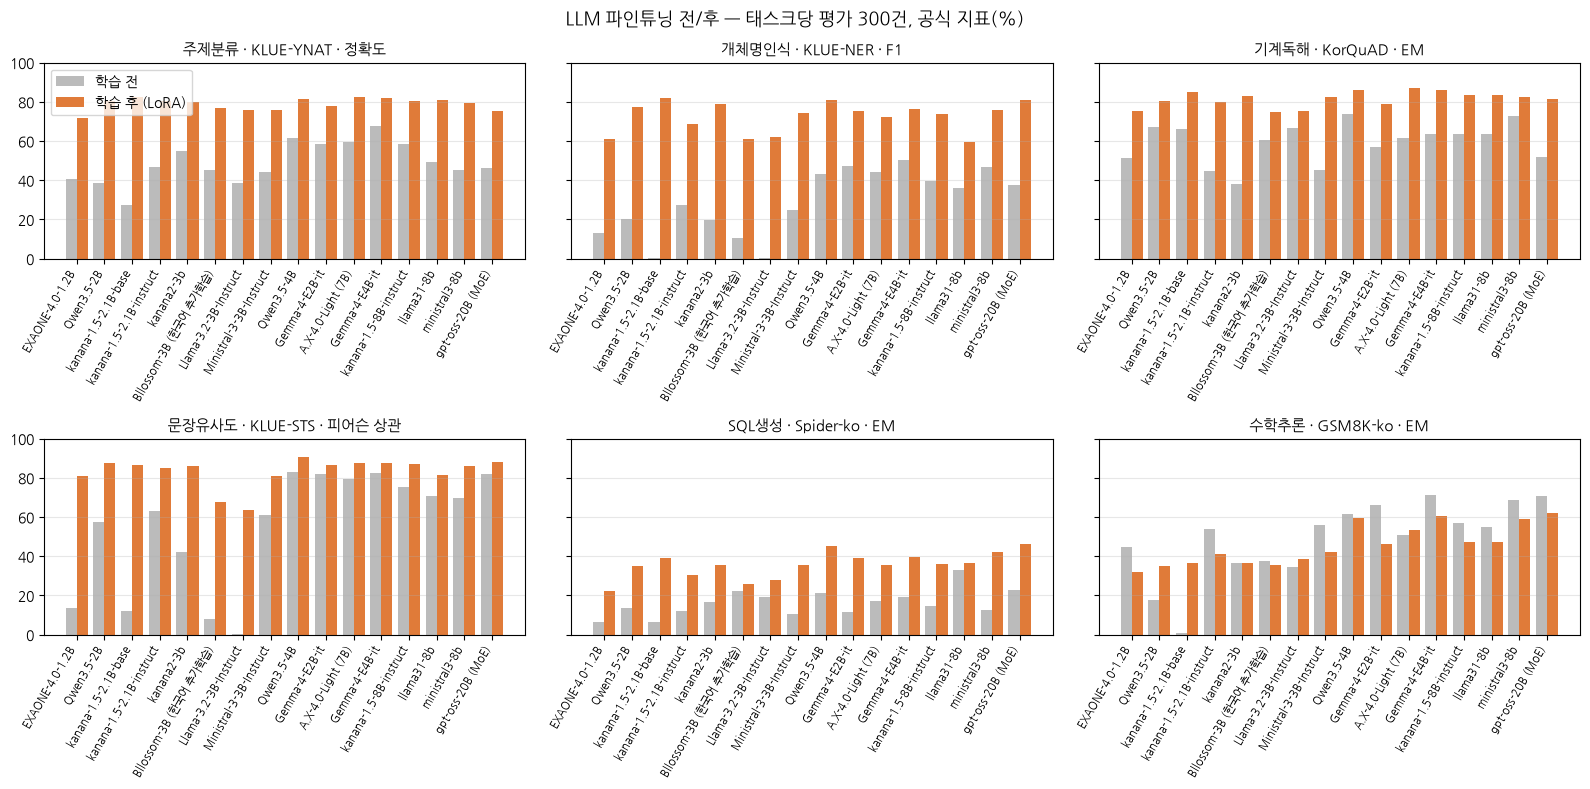

In [18]:
if len(llm):
    fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharey=True)
    for ax, task in zip(axes.flat, TASK_ORDER):
        sub = llm[llm["task"] == task].set_index("model").reindex(order)
        x = range(len(sub))
        ax.bar([i - 0.2 for i in x], pd.to_numeric(sub["before"], errors="coerce"),
               width=0.4, color=C_BEFORE, label="학습 전")
        ax.bar([i + 0.2 for i in x], pd.to_numeric(sub["after"], errors="coerce"),
               width=0.4, color=C_AFTER, label="학습 후 (LoRA)")
        ax.set_title(TASK_LABEL[task].replace("\n", " · "), fontsize=11)
        ax.set_xticks(list(x)); ax.set_xticklabels(sub.index, rotation=60, ha="right", fontsize=8)
        ax.set_ylim(0, 100); ax.grid(axis="y", alpha=0.3)
    axes[0, 0].legend(loc="upper left")
    fig.suptitle("LLM 파인튜닝 전/후 — 태스크당 평가 300건, 공식 지표(%)", fontsize=13)
    plt.tight_layout(); plt.show()
else:
    print("LLM 결과가 아직 없습니다.")

In [19]:
# 태스크를 '평균 상승폭' 순서로 줄 세우고, 학습 후에 도달한 절대 수준도 같이 본다.
if len(llm) and llm["delta"].notna().any():
    g = llm.groupby("task").agg(평균_학습전=("before", "mean"), 평균_학습후=("after", "mean"),
                                평균_상승폭=("delta", "mean"))
    g = drop_empty(g.reindex([t for t in TASK_ORDER if t in g.index])).round(1)
    g.index = [f"{TASK_NAME[t]} ({METRIC_KO[MAIN_METRIC[t]]})" for t in g.index]
    display(g.sort_values("평균_상승폭", ascending=False))
    top = g["평균_상승폭"].idxmax(); bot = g["평균_상승폭"].idxmin()
    print(f"가장 많이 오른 태스크: {top} ({g.loc[top, '평균_상승폭']:+.1f}p, 학습 후 {g.loc[top, '평균_학습후']})")
    print(f"가장 적게 오른 태스크: {bot} ({g.loc[bot, '평균_상승폭']:+.1f}p, 학습 후 {g.loc[bot, '평균_학습후']})")
    low = g[g["평균_학습후"] < 50]
    if len(low):
        print("학습 후에도 절반을 못 넘긴 태스크:", ", ".join(low.index))
else:
    print("학습 후 점수가 아직 없어 상승폭을 계산할 수 없습니다.")

,평균_학습전,평균_학습후,평균_상승폭
개체명인식 (F1),28.8,72.5,43.7
주제분류 (정확도),48.9,79.0,30.1
문장유사도 (피어슨 상관),55.1,83.3,28.2
기계독해 (EM),59.1,81.6,22.5
SQL생성 (EM),16.2,35.7,19.5
수학추론 (EM),48.8,45.7,-3.1


가장 많이 오른 태스크: 개체명인식 (F1) (+43.7p, 학습 후 72.5)
가장 적게 오른 태스크: 수학추론 (EM) (-3.1p, 학습 후 45.7)
학습 후에도 절반을 못 넘긴 태스크: SQL생성 (EM), 수학추론 (EM)


In [20]:
# 형식 깨짐이 학습으로 얼마나 줄었나 — '형식을 배웠다'의 가장 직접적인 증거
if len(llm) and llm[["broken_before", "broken_after"]].notna().any().any():
    bf = llm.groupby("task")[["broken_before", "broken_after"]].mean()
    bf = drop_empty(bf.reindex([t for t in TASK_ORDER if t in bf.index])).round(1)
    bf.index = [TASK_NAME[t] for t in bf.index]
    bf.columns = ["학습 전 (300건 중)", "학습 후 (300건 중)"]
    print("형식 깨짐 평균 건수 — 채점기가 답을 읽어내지 못한 횟수")
    display(bf)
else:
    print("형식 깨짐 집계가 아직 없습니다.")

형식 깨짐 평균 건수 — 채점기가 답을 읽어내지 못한 횟수


,학습 전 (300건 중),학습 후 (300건 중)
주제분류,8.6,0.8
개체명인식,12.6,4.9
문장유사도,0.0,0.0
SQL생성,3.6,0.0
수학추론,57.1,9.3


**읽는 법 — 세 종류로 나눠 보세요**

위 출력에서 태스크가 대체로 세 무리로 갈립니다. 어느 무리에 속하는지는 **표를 보고 판단하세요.**

1. **출력 형식만 맞추면 되는 태스크.** 라벨 목록에서 하나를 고르거나 숫자 하나를 쓰면 되는 일입니다
   (주제분류·문장유사도). 모델은 답을 몰라서가 아니라 *우리가 정한 형식으로 쓰지 못해서* 학습 전 점수가 낮습니다.
   몇백 건이면 형식을 배우고, 상승폭이 가장 큽니다. **파인튜닝이 가장 잘 가르치는 것은 형식과 라벨 어휘입니다.**
2. **형식 + 정확한 옮겨 쓰기가 필요한 태스크.** 개체명인식·기계독해는 지문에서 정확한 구간을 찾아
   정해진 형태로 써야 합니다. 형식을 배우면 크게 오르지만, 절대 점수는 전체 데이터로 학습한 BERT에
   못 미치는 경우가 많습니다(§2).
3. **없던 능력이 필요한 태스크.** 수학추론은 계산을, SQL생성은 스키마 이해를 요구합니다.
   상승폭이 작고 학습 후에도 점수가 낮다면, 그것은 **파인튜닝이 못 가르친 부분**입니다.
   이럴 때 필요한 것은 예제 몇백 건이 아니라 더 큰 모델, 더 많은 사전학습, 또는 다른 접근(도구 사용·검증기)입니다.
   **수학추론은 학습 뒤 오히려 떨어지는 모델이 여럿입니다.** 위 표의 상승폭이 음수인 칸을 찾아 보세요.
   번역된 GSM8K-ko 풀이의 문체를 흉내 내다 자기 계산 습관이 흐트러지고, 같은 문장을 되풀이하다 길이 제한에 걸리는 예가
   나옵니다(`pick_demos.py`가 뽑은 실제 출력이 `DEMO-SCRIPT.md`에 있습니다). 파인튜닝은 **공짜가 아닙니다** — 원래 잘하던 것을
   잃을 수 있고(망각), 그래서 학습 전 점수를 반드시 같은 평가로 재 두어야 합니다.

> 파인튜닝을 "모델을 똑똑하게 만드는 일"로 생각하면 어긋납니다.
> **이미 아는 것을 우리가 원하는 형태로 꺼내게 만드는 일**에 가깝습니다.
> 그래서 형식이 문제였던 태스크는 극적으로 오르고, 능력이 문제였던 태스크는 조금밖에 오르지 않습니다.

## 5. 몇 에폭을 돌려야 하나 — 1 · 2 · 3에폭 실험

같은 모델, 같은 데이터로 **에폭 수만** 바꿔 학습했습니다. 에폭은 학습 데이터를 몇 번 반복해 보여 주는지입니다.
많이 볼수록 좋을 것 같지만, 학습 데이터에 지나치게 맞춰지면(과적합) 평가 점수는 오히려 떨어질 수 있습니다.

In [21]:
def epoch_of(tag):
    m = re.search(r"-(\d+)ep$", str(tag))
    return int(m.group(1)) if m else 1

def base_tag(tag):
    return re.sub(r"-(\d+)ep$", "", str(tag))

ep = pd.DataFrame()
if len(llm_all):
    tags = set(llm_all["tag"].dropna().astype(str))
    bases = sorted({base_tag(t) for t in tags if re.search(r"-\d+ep$", t)})
    if bases:
        ep = llm_all[llm_all["tag"].astype(str).map(base_tag).isin(bases)].copy()
        ep["에폭"] = ep["tag"].map(epoch_of)
        ep["모델"] = ep["tag"].astype(str).map(lambda t: MODEL_INFO.get(base_tag(t), {}).get("name", base_tag(t)))

if len(ep):
    tbl = pivot_tasks(ep, "after", TASK_ORDER, index=["모델", "에폭"])
    tbl = tbl.join(ep.groupby(["모델", "에폭"]).agg(학습분=("train_min", "first"),
                                                  GPU_GB=("peak_gpu_gb", "first"))).round(1)
    display(tbl)
else:
    print("에폭 실험 결과(<tag>-2ep, -3ep)가 아직 없습니다.")

주제분류  개체명인식  기계독해  문장유사도  SQL생성  수학추론    평균   학습분  GPU_GB
모델              에폭                                                           
EXAONE-4.0-1.2B 1   71.7   60.8  75.3   80.8   22.3  32.0  57.1   9.9     4.3
                2   76.0   69.2  76.3   83.8   27.7  37.7  61.8  19.2     4.3
                3   77.0   69.8  74.3   85.6   27.0  34.7  61.4  28.8     4.3

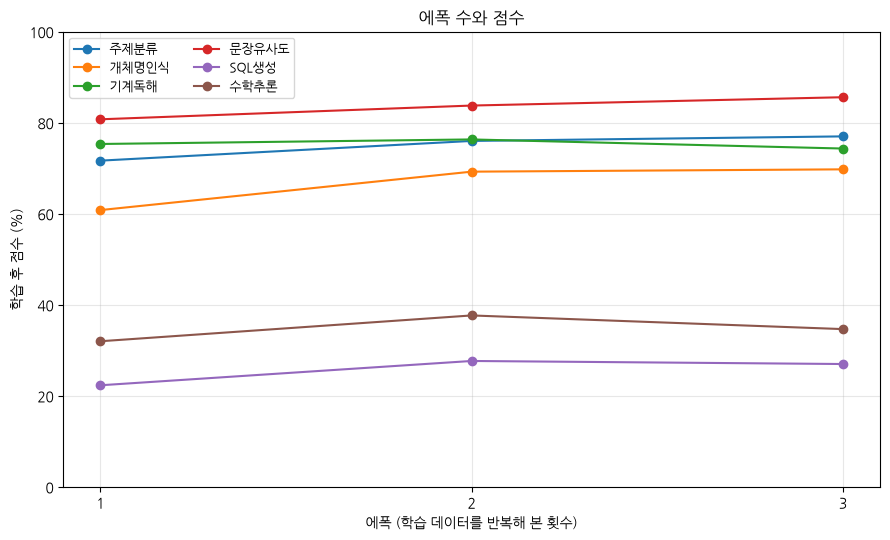

에폭별 여섯 태스크 평균: 1에폭 57.1, 2에폭 61.8, 3에폭 61.4
에폭별 학습 시간(분):   1에폭 9.9, 2에폭 19.2, 3에폭 28.8
평균이 가장 높은 지점: 2에폭 (61.8). 가장 적은 에폭 대비 학습 시간은 약 1.9배입니다.


In [22]:
if len(ep):
    fig, ax = plt.subplots(figsize=(9, 5.5))
    for task in TASK_ORDER:
        s = ep[ep["task"] == task].groupby("에폭")["after"].mean().sort_index()
        s = pd.to_numeric(s, errors="coerce").dropna()
        if len(s):
            ax.plot(s.index, s.values, marker="o", label=TASK_NAME[task])
    ax.set_xlabel("에폭 (학습 데이터를 반복해 본 횟수)"); ax.set_ylabel("학습 후 점수 (%)")
    ax.set_xticks(sorted(ep["에폭"].unique())); ax.set_ylim(0, 100); ax.grid(alpha=0.3)
    ax.legend(fontsize=9, ncol=2); ax.set_title("에폭 수와 점수")
    plt.tight_layout(); plt.show()

    mean_by_ep = ep.groupby("에폭")["after"].mean().round(1)
    time_by_ep = ep.groupby("에폭")["train_min"].first().round(1)
    print("에폭별 여섯 태스크 평균:", ", ".join(f"{k}에폭 {v}" for k, v in mean_by_ep.items()))
    print("에폭별 학습 시간(분):  ", ", ".join(f"{k}에폭 {v}" for k, v in time_by_ep.items()))
    best = mean_by_ep.idxmax()
    print(f"평균이 가장 높은 지점: {best}에폭 ({mean_by_ep[best]}). "
          f"가장 적은 에폭 대비 학습 시간은 약 {time_by_ep[best] / max(time_by_ep.iloc[0], 1e-9):.1f}배입니다.")
else:
    print("에폭 실험 결과가 아직 없습니다.")

**읽는 법**

- **에폭을 늘리면 학습 시간은 비례해서 늘어납니다.** 점수도 그만큼 오르는지 위 숫자로 확인하세요.
  오르는 폭이 시간에 비해 작다면, 강의 실습처럼 시간이 정해진 상황에서는 1에폭이 합리적인 선택입니다.
- **태스크마다 최적 에폭이 다를 수 있습니다.** 형식만 배우면 되는 태스크는 1에폭에서 이미 거의 끝나고,
  출력이 긴 태스크는 조금 더 볼 때 나아지기도 합니다. 선이 서로 엇갈리는지 보세요.
- **점수가 내려가는 선이 있다면 과적합 신호입니다.** 학습 데이터의 표현을 외워 버려
  처음 보는 문장에서 손해를 봅니다. 이럴 때는 에폭을 줄이거나 데이터를 늘립니다.
- 실습에서는 `train.py --epochs 2` 처럼 바꿀 수 있습니다. 다만 GPU 한 장을 오래 잡으므로
  강의 중에는 1에폭으로 돌리고, 위 표로 "더 돌리면 어떻게 되는지"를 확인하세요.

## 6. 비용 — 학습 시간 · GPU 메모리 · 추론 지연 · 모델 크기

성능만 보고 고를 수는 없습니다. 네 가지를 봅니다.

- **학습 시간** — 한 번 만드는 데 드는 시간. BERT·T5는 태스크 수만큼 반복해야 합니다.
- **GPU 메모리** — 어떤 장비가 필요한지를 결정합니다.
- **추론 지연** — 서비스에서 매 요청마다 드는 비용. 한 번 만들고 끝이 아니라 **계속** 듭니다.
- **모델 크기** — 배포하고 보관해야 하는 파일의 크기.

In [23]:
# LLM 모델별 비용 — 여섯 태스크를 한 번에 학습한 값
if len(llm):
    cl = llm.groupby(["model", "kind"], as_index=False).agg(
        총파라미터_B=("params_b", "first"), 학습파라미터_M=("trainable_m", "first"),
        학습분=("train_min", "first"), GPU_GB=("peak_gpu_gb", "first"),
        추론초_6태스크=("after_sec", sum1), 학습후평균=("after", "mean"))
    cl = cl.set_index("model").reindex(by_size(llm)).round(1)
    display(cl)
else:
    print("LLM 결과가 아직 없습니다.")

,kind,총파라미터_B,학습파라미터_M,학습분,GPU_GB,추론초_6태스크,학습후평균
model,,,,,,,
EXAONE-4.0-1.2B,Instruct,1.3,15.2,9.9,4.3,386.4,57.1
Qwen3.5-2B,Instruct,1.9,16.8,34.8,7.1,395.7,66.0
kanana-1.5-2.1B-base,Base,2.1,23.0,15.4,6.1,289.1,68.6
kanana-1.5-2.1B-instruct,Instruct,2.1,23.0,24.4,6.1,284.2,64.2
kanana2-3b,?,3.2,27.0,13.5,8.8,377.3,66.7
Bllossom-3B (한국어 추가학습),Instruct,3.2,24.3,32.4,9.3,308.6,56.9
Llama-3.2-3B-Instruct,Instruct,3.2,24.3,15.9,9.3,274.1,57.1
Ministral-3-3B-Instruct,Instruct,3.9,24.7,22.2,10.5,290.1,65.3
Qwen3.5-4B,Instruct,4.2,32.5,40.9,12.7,497.8,73.9


In [24]:
# BERT·T5 모델별 비용 — 네 태스크를 각각 학습한 값의 합
base_rows = []
for fam, df in [("BERT", bert), ("T5", t5)]:
    if not len(df):
        continue
    s = df[df["task"].isin(THREE_WAY_TASKS)]
    g = s.groupby(["model", "mode"]).agg(파라미터_M=("params_m", "first"), 학습분_4태스크=("train_min", sum1),
                                         GPU_GB=("peak_gpu_gb", "max"), 추론초_4태스크=("eval_sec", sum1),
                                         평균점수=("score", "mean"), 학습한태스크수=("task", "count"))
    g["방식"] = fam
    base_rows.append(g)
if base_rows:
    cb = pd.concat(base_rows).reset_index().set_index(["방식", "model", "mode"]).round(1)
    display(cb.sort_index())
else:
    print("BERT·T5 결과가 아직 없습니다.")

파라미터_M  학습분_4태스크  GPU_GB  추론초_4태스크  평균점수  학습한태스크수
방식   model              mode                                                     
BERT KLUE-BERT-base     budget   110.0       0.4     6.2       0.8  76.9        4
                        full     110.0       7.3     6.2       0.8  85.9        4
     KLUE-RoBERTa-base  budget   110.0       0.4     6.2       0.7  76.2        4
                        full     110.0       7.4     6.2       0.8  86.6        4
     KLUE-RoBERTa-large budget   335.6       1.5    16.7       3.0  83.5        4
                        full     335.6      20.1    16.7       1.9  88.1        4
     KLUE-RoBERTa-small budget    67.5       0.3     3.4       0.5  72.1        4
                        full      67.5       4.2     3.4       0.5  85.8        4
     KoELECTRA-base-v3  budget   112.3       0.4     6.2       0.8  55.5        4
                        full     112.3       7.5     6.2       0.8  85.7        4
T5   pko-T5-base        budget   275.6       7.9    14.6     130.1  72.5        4
                        full     275.6      90.8    42.9      75.1  83.8        4

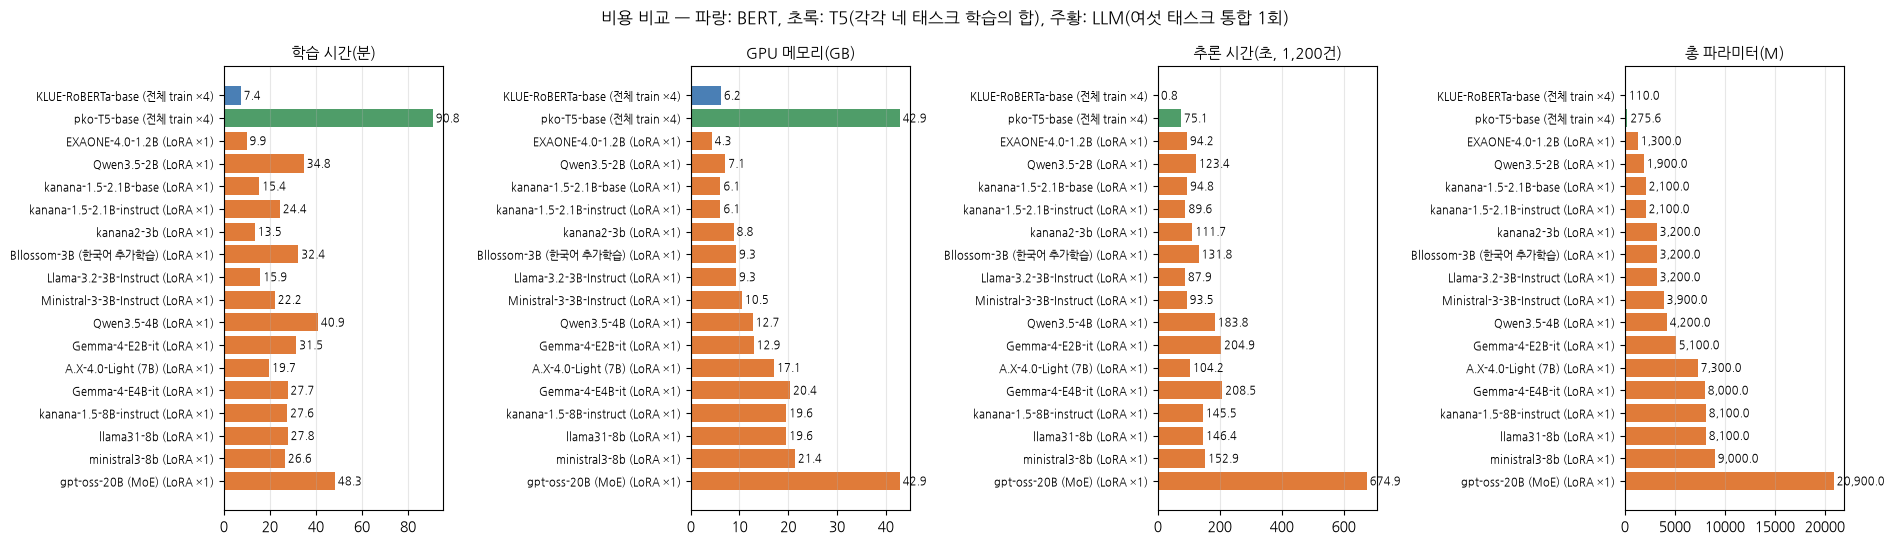

,학습 시간(분),GPU 메모리(GB),"추론 시간(초, 1,200건)",총 파라미터(M)
이름,,,,
KLUE-RoBERTa-base (전체 train ×4),7.4,6.2,0.8,110.0
pko-T5-base (전체 train ×4),90.8,42.9,75.1,275.6
EXAONE-4.0-1.2B (LoRA ×1),9.9,4.3,94.2,1300.0
Qwen3.5-2B (LoRA ×1),34.8,7.1,123.4,1900.0
kanana-1.5-2.1B-base (LoRA ×1),15.4,6.1,94.8,2100.0
kanana-1.5-2.1B-instruct (LoRA ×1),24.4,6.1,89.6,2100.0
kanana2-3b (LoRA ×1),13.5,8.8,111.7,3200.0
Bllossom-3B (한국어 추가학습) (LoRA ×1),32.4,9.3,131.8,3200.0
Llama-3.2-3B-Instruct (LoRA ×1),15.9,9.3,87.9,3200.0


In [25]:
# 세 방식을 한 그림에 — 네 태스크 기준으로 맞춰 비교한다
rows = []
if len(bert) and BERT_REF:
    s = bert[(bert["model"] == BERT_REF) & (bert["mode"] == "full") & (bert["task"].isin(THREE_WAY_TASKS))]
    rows.append({"이름": f"{BERT_REF} (전체 train ×4)", "색": C_BERT, "학습 시간(분)": agg(s, "train_min", "sum"),
                 "GPU 메모리(GB)": agg(s, "peak_gpu_gb", "max"), "추론 시간(초, 1,200건)": agg(s, "eval_sec", "sum"),
                 "총 파라미터(M)": agg(s, "params_m", "first")})
if len(t5) and T5_REF:
    s = t5[(t5["model"] == T5_REF) & (t5["mode"] == "full") & (t5["task"].isin(THREE_WAY_TASKS))]
    rows.append({"이름": f"{T5_REF} (전체 train ×4)", "색": C_T5, "학습 시간(분)": agg(s, "train_min", "sum"),
                 "GPU 메모리(GB)": agg(s, "peak_gpu_gb", "max"), "추론 시간(초, 1,200건)": agg(s, "eval_sec", "sum"),
                 "총 파라미터(M)": agg(s, "params_m", "first")})
for m in by_size(llm):
    s = llm[llm["model"] == m]
    s4 = s[s["task"].isin(THREE_WAY_TASKS)]
    rows.append({"이름": f"{m} (LoRA ×1)", "색": C_AFTER, "학습 시간(분)": agg(s, "train_min", "first"),
                 "GPU 메모리(GB)": agg(s, "peak_gpu_gb", "first"), "추론 시간(초, 1,200건)": agg(s4, "after_sec", "sum"),
                 "총 파라미터(M)": (agg(s, "params_b", "first") or 0) * 1000 or None})

COST_COLS = ["학습 시간(분)", "GPU 메모리(GB)", "추론 시간(초, 1,200건)", "총 파라미터(M)"]
cost = pd.DataFrame(rows)
if len(cost):
    cost = cost.set_index("이름")
    cost = cost[cost[COST_COLS].notna().any(axis=1)]      # 아직 아무 값도 없는 줄은 뺀다
if len(cost):
    fig, axes = plt.subplots(1, 4, figsize=(19, 5.5))
    for ax, col in zip(axes, COST_COLS):
        v = pd.to_numeric(cost[col], errors="coerce")
        ax.barh(range(len(cost)), v, color=cost["색"])
        ax.set_yticks(range(len(cost))); ax.set_yticklabels(cost.index, fontsize=8)
        ax.invert_yaxis(); ax.set_title(col, fontsize=11); ax.grid(axis="x", alpha=0.3)
        for i, x in enumerate(v):
            if pd.notna(x):
                ax.text(x, i, f" {x:,.1f}", va="center", fontsize=8)
    fig.suptitle("비용 비교 — 파랑: BERT, 초록: T5(각각 네 태스크 학습의 합), 주황: LLM(여섯 태스크 통합 1회)", fontsize=12)
    plt.tight_layout(); plt.show()
    display(cost.drop(columns="색").round(1))
else:
    print("비용을 그릴 결과가 아직 없습니다.")

In [26]:
# 몇 배 차이인지 한 줄로
if len(cost) >= 2:
    v = pd.to_numeric(cost["추론 시간(초, 1,200건)"], errors="coerce").dropna()
    if len(v) >= 2:
        print(f"추론 시간: 가장 빠른 {v.idxmin()} {v.min():.1f}초 → 가장 느린 {v.idxmax()} {v.max():.1f}초 "
              f"(약 {v.max() / max(v.min(), 1e-9):.0f}배)")
    p = pd.to_numeric(cost["총 파라미터(M)"], errors="coerce").dropna()
    if len(p) >= 2:
        print(f"모델 크기:  {p.min():,.0f}M → {p.max():,.0f}M (약 {p.max() / max(p.min(), 1e-9):.0f}배)")

추론 시간: 가장 빠른 KLUE-RoBERTa-base (전체 train ×4) 0.8초 → 가장 느린 gpt-oss-20B (MoE) (LoRA ×1) 674.9초 (약 844배)
모델 크기:  110M → 20,900M (약 190배)


**읽는 법**

- **추론 속도는 인코더가 압도적입니다.** BERT는 문장을 한 번 읽고 라벨 하나를 내지만,
  T5와 LLM은 답을 **한 토큰씩** 만듭니다. 답이 길수록(개체명 목록, 수학 풀이) 그만큼 더 걸립니다.
  하루에 수백만 건을 처리하는 서비스라면 이 차이가 곧 요금입니다.
- **학습 비용은 반대 방향입니다.** LLM은 LoRA로 전체의 1% 남짓만 학습하고, 여섯 태스크를 한 번에 끝냅니다.
  BERT·T5는 태스크마다 처음부터 다시 학습합니다. 태스크가 늘어날수록 이 쪽이 불리해집니다.
- **GPU 메모리는 모델 크기를 따라갑니다.** 24GB 카드라면 4B급까지가 현실적이고,
  그 이상은 4비트 양자화(QLoRA)나 더 큰 GPU가 필요합니다.
- **저장·배포**: BERT·T5는 태스크마다 수백 MB짜리 모델 파일이 하나씩, LLM은 수십 MB짜리 어댑터 하나입니다.
  단, 어댑터를 쓰려면 원본 모델(수 GB)이 서버에 올라가 있어야 합니다.
- 모델 계열에 따라 크기 대비 속도가 크게 다를 수 있습니다(어텐션 구현·커널 최적화 차이).
  "**같은 크기면 같은 속도**"라고 가정하지 말고 직접 재 보세요 — 위 표가 그 재 본 결과입니다.

## 7. 이전 구성에서 얻은 교훈

이 절의 숫자는 모두 **이전 6태스크 구성**(감성분류 NSMC · 자연어추론 KLUE-NLI 포함, `results/sweep`·`results/ablation`)의
결과입니다. 평가셋과 학습 데이터가 지금과 다르므로 **앞 절들의 표와 같은 줄에 놓고 비교하지 마세요.**
그래도 여기서 얻은 두 가지는 지금 구성에도 그대로 적용됩니다.

In [27]:
def raw_sweep(sub, tasks):
    # compare.load_sweep() 은 지금 구성의 태스크만 읽는다. 이전 구성에만 있던 태스크
    # (감성분류·자연어추론)까지 보려면 JSON을 직접 읽어야 한다.
    d = Path(RES) / sub
    rows = []
    if not d.is_dir():
        return pd.DataFrame(columns=["tag", "model", "task", "when", "score", "train_min", "loss_mode", "template"])
    for mp in sorted(d.glob("*-train_meta.json")):
        tag = mp.name[: -len("-train_meta.json")]
        try:
            meta = json.loads(mp.read_text(encoding="utf-8"))
        except Exception:
            meta = {}
        info = MODEL_INFO.get(tag, {})
        tmpl = "plain" if (meta.get("chat_template") == "plain"
                           or (meta.get("template_fix") or {}).get("action") == "plain") else "native"
        for when in ("before", "after"):
            f = d / f"{tag}-{when}.json"
            if not f.exists():
                continue
            try:
                res = json.loads(f.read_text(encoding="utf-8")).get("results", {})
            except Exception:
                continue
            for t in tasks:
                m = MAIN_METRIC.get(t)
                if isinstance(res.get(t), dict) and res[t].get(m) is not None:
                    rows.append({"tag": tag, "model": info.get("name", tag), "task": t, "when": when,
                                 "score": res[t][m], "train_min": round(meta.get("train_seconds", 0) / 60, 1),
                                 "loss_mode": meta.get("loss_mode"), "template": tmpl})
    return pd.DataFrame(rows)

OLD_TASKS = ["cls", "ner", "mrc", "tc", "nli", "sts"]     # 이전 구성의 여섯 태스크
old = raw_sweep("sweep", OLD_TASKS)
old_abl = raw_sweep("ablation", OLD_TASKS)
print(f"이전 구성 — sweep {old['model'].nunique() if len(old) else 0}종, "
      f"ablation {old_abl['model'].nunique() if len(old_abl) else 0}종")

이전 구성 — sweep 13종, ablation 4종


### 7-1. 왜 문장유사도를 남기고 자연어추론을 뺐나

두 태스크는 **학습이 끝나면 점수가 거의 같습니다.** 다른 것은 출발점입니다.
문장유사도는 학습 전에 형편없다가 학습 후에 크게 오르고, 자연어추론은 처음부터 어느 정도 하다가 조금 오릅니다.
수업에서 "파인튜닝이 무엇을 바꾸는가"를 보여 주기에는 앞의 그림이 훨씬 분명합니다.

In [28]:
if len(old):
    two = old[old["task"].isin(["sts", "nli"])]
    if len(two):
        t = two.pivot_table(index="model", columns=["task", "when"], values="score", aggfunc="first")
        t = t.reindex(columns=[(a, b) for a in ["sts", "nli"] if a in t.columns.get_level_values(0)
                               for b in ["before", "after"]], fill_value=np.nan)
        t.columns = [f"{TASK_NAME[a]} {'학습 전' if b == 'before' else '학습 후'}" for a, b in t.columns]
        for task, ko in [("sts", "문장유사도"), ("nli", "자연어추론")]:
            c_b, c_a = f"{ko} 학습 전", f"{ko} 학습 후"
            if c_b in t.columns and c_a in t.columns:
                t[f"{ko} 상승폭"] = t[c_a] - t[c_b]
        display(t.round(1))
        m = two.groupby(["task", "when"])["score"].mean().round(1)
        for task, ko in [("sts", "문장유사도"), ("nli", "자연어추론")]:
            if (task, "after") in m.index:
                b_, a_ = m.get((task, "before"), np.nan), m[(task, "after")]
                print(f"{ko}: 학습 전 평균 {b_} → 학습 후 평균 {a_} (상승폭 {a_ - b_:+.1f}p)")
    else:
        print("이전 구성의 문장유사도·자연어추론 결과가 없습니다.")
else:
    print("results/sweep/ 가 없습니다.")

,문장유사도 학습 전,문장유사도 학습 후,자연어추론 학습 전,자연어추론 학습 후,문장유사도 상승폭,자연어추론 상승폭
model,,,,,,
A.X-4.0-Light (7B),79.3,86.6,87.7,88.3,7.3,0.7
EXAONE-4.0-1.2B,13.7,79.9,56.0,77.3,66.3,21.3
Gemma-4-E2B-it,82.0,83.5,73.3,83.7,1.5,10.3
Gemma-4-E4B-it,82.7,85.4,80.3,88.0,2.7,7.7
Mi:dm-2.0-Mini (2.3B),4.0,75.4,46.0,83.3,71.4,37.3
Qwen3.5-0.8B,44.7,84.3,32.3,70.7,39.6,38.3
Qwen3.5-0.8B-Base,-17.6,85.4,32.3,73.7,103.0,41.3
Qwen3.5-2B,57.6,85.6,54.3,84.3,28.0,30.0
Qwen3.5-2B-Base,31.6,86.6,41.3,85.7,55.0,44.3


문장유사도: 학습 전 평균 47.0 → 학습 후 평균 84.4 (상승폭 +37.4p)
자연어추론: 학습 전 평균 58.2 → 학습 후 평균 83.1 (상승폭 +24.9p)


> 정리하면, 학습 후 도달점은 비슷한데 **학습 전 출발점이 크게 다릅니다.**
> 여기에 "두 문장이 얼마나 비슷한가를 0~5점으로"라는 설명의 쉬움이 더해져 문장유사도를 남겼습니다.
> 감성분류(NSMC)는 학습 전에도 이미 높아서(위 표의 이전 구성 결과에서 확인할 수 있습니다)
> 세 방식의 차이를 드러내지 못해 뺐습니다.

### 7-2. 손실을 어디에 걸 것인가 — 이전 구성에서의 대조 실험

학습할 때 모델에게 "틀렸다"고 알려 주는 범위(손실 범위)를 어디로 잡느냐가 점수를 바꿉니다.

- **답변 부분에만 손실** — 지시문과 입력은 그냥 읽고, 답변만 맞히도록 학습
- **전체 시퀀스 손실** — 지시문·입력까지 전부 이어 쓰도록 학습

두 번째가 나쁜 것은 아니지만, 학습 신호가 지시문을 따라 쓰는 데 나뉩니다.
어느 쪽이 유리한지 확인하려고 이전 구성에서 **대화 형식 × 손실 범위**를 하나씩만 바꿔 학습해 보았습니다
(`train.py --plain-template`, `--full-loss`).

In [29]:
abl = pd.concat([old, old_abl], ignore_index=True) if len(old_abl) else old
if len(abl):
    a = abl[abl["when"] == "after"].copy()
    a["손실 범위"] = a["loss_mode"].fillna("?").astype(str).map(
        lambda s: "답변 부분에만" if "답변" in s or "completion" in s.lower() else "전체 시퀀스")
    a["대화 형식"] = a["template"].map({"plain": "단순 형식", "native": "모델 고유"}).fillna("?")
    a["모델"] = a["model"].str.replace(r"\s*\(.*\)$", "", regex=True)
    keep = a.groupby("모델")["tag"].nunique()
    a = a[a["모델"].isin(keep[keep > 1].index)]            # 조건을 바꿔 여러 번 돌린 모델만
    if len(a):
        t = a.pivot_table(index=["모델", "대화 형식", "손실 범위"], columns="task", values="score", aggfunc="first")
        t = t.reindex(columns=[c for c in OLD_TASKS if c in t.columns])
        t.columns = [TASK_NAME[c] for c in t.columns]
        t["평균"] = t.mean(axis=1)
        t = t.join(a.groupby(["모델", "대화 형식", "손실 범위"]).agg(학습분=("train_min", "first")))
        display(t.round(1))
        g = a.groupby("손실 범위")["score"].mean().round(1)
        if len(g) == 2:
            hi, lo = g.idxmax(), g.idxmin()
            print(f"손실 범위별 평균: {hi} {g[hi]} vs {lo} {g[lo]} (차이 {g[hi] - g[lo]:+.1f}p)")
        per = a.pivot_table(index="task", columns="손실 범위", values="score", aggfunc="mean")
        if per.shape[1] == 2:
            per["차이"] = (per.iloc[:, 0] - per.iloc[:, 1]).round(1)
            per.index = [TASK_NAME[i] for i in per.index]
            print("\n태스크별 차이 (이전 6태스크 구성 기준)")
            display(per.round(1))
    else:
        print("조건을 바꿔 여러 번 학습한 모델이 없습니다.")
else:
    print("이전 구성 결과가 없습니다.")

감성분류  개체명인식  기계독해  주제분류  자연어추론  문장유사도    평균   학습분
모델                       대화 형식 손실 범위                                                     
EXAONE-4.0-1.2B          단순 형식 답변 부분에만  85.7   74.1  78.0  71.0   80.0   81.8  78.4   8.7
                         모델 고유 전체 시퀀스   87.3   63.0  75.3  69.0   77.3   79.9  75.3   9.3
Gemma-4-E2B-it           단순 형식 답변 부분에만  89.3   79.3  84.7  81.7   82.0   82.6  83.3  15.2
                         모델 고유 전체 시퀀스   90.0   75.6  77.7  77.7   83.7   83.5  81.3  16.7
kanana-1.5-2.1B-base     단순 형식 답변 부분에만  91.3   82.3  85.3  81.3   86.3   84.6  85.2  11.0
                               전체 시퀀스   91.7   69.6  82.7  82.3   82.7   84.3  82.2  11.8
kanana-1.5-2.1B-instruct 단순 형식 답변 부분에만  90.7   81.2  85.0  81.0   86.0   84.7  84.8  11.0
                         모델 고유 전체 시퀀스   92.0   68.0  82.3  80.0   81.7   84.7  81.5  12.0

손실 범위별 평균: 답변 부분에만 82.9 vs 전체 시퀀스 80.1 (차이 +2.8p)

태스크별 차이 (이전 6태스크 구성 기준)


손실 범위,답변 부분에만,전체 시퀀스,차이
감성분류,89.2,90.2,-1.0
기계독해,83.2,79.5,3.8
개체명인식,79.2,69.0,10.2
자연어추론,83.6,81.3,2.2
문장유사도,83.4,83.1,0.3
주제분류,78.8,77.2,1.5


**읽는 법 (모두 이전 6태스크 구성 기준)**

- **차이가 가장 크게 나는 곳은 출력이 길고 형식이 엄격한 태스크입니다.** 개체명인식처럼 JSON 배열을 통째로
  써야 하는 태스크에서, 답변에만 손실을 건 쪽이 크게 앞섰습니다. 라벨 한 단어만 쓰면 되는 태스크는 거의 차이가 없습니다.
- **Base 모델이 Instruct 모델을 앞서는 것처럼 보였던 현상도 여기서 설명됩니다.** 원인은 모델 종류가 아니라,
  그 모델의 대화 형식에서 학습 도구가 "답변 구간"을 찾아내지 못해 전체 시퀀스로 학습되었다는 데 있었습니다.
  같은 조건으로 맞추자 둘의 차이는 거의 사라졌습니다.
- **손실 값(loss)은 두 조건 사이에 비교하면 안 됩니다.** 세는 토큰이 다르니 당연히 다릅니다. 점수로만 비교하세요.
- **주의**: 모델이 사전학습에서 본 적 없는 형식을 강제하면, 원래 알던 라벨 어휘가 새어 나오거나
  생성이 흔들려 **오히려 나빠지는 태스크**가 생길 수 있습니다. 위 표에서 태스크별 부호가 엇갈리는지 확인하세요.
  이득이 큰 조치라도 모델마다 값을 치릅니다.

> 실습에서는 `train.py --plain-template`로 켤 수 있습니다. 노트북의 기본 경로는 모델 고유 형식을 그대로 씁니다 —
> "모델이 원래 쓰던 대화 형식을 존중한다"가 먼저 배울 원칙이고, 이 옵션은 그 다음에 시험해 볼 개선입니다.

## 8. 사례 연구 — 점수표만 봤다면 잘못 끝났을 일

스윕을 돌리는 동안 "모델이 답을 쓰고 **멈추지 못하는**" 문제를 서로 다른 원인으로 두 번 만났습니다.
둘 다 점수만 봤다면 "이 모델은 못 배운다"로 끝났을 일이고, **출력을 직접 읽어서** 원인을 찾았습니다.
아래 두 사례는 생성 방식(T5·LLM)에만 있는 종류의 문제입니다 — BERT에는 "멈춘다"는 개념 자체가 없습니다.

### 사례 A. 학습된 적 없는 종료 토큰

기계독해 EM이 학습 **후에** 0점으로 떨어진 모델이 있었습니다. F1은 0이 아니었습니다
— 정답 단어는 들어 있는데 **뒤에 군말이 붙었다**는 뜻입니다. 출력을 열어 보니 이런 모습이었습니다.

```
정답: 1989년
모델: 1989년Ā:semicolonĀĀ1999년: 3월ĀĀ ... (멈추지 않고 이어짐)
```

- 채팅 템플릿은 답변 끝에 `<|eot_id|>` 같은 **턴 종료 토큰**을 붙입니다. 모델은 이 토큰을 생성해야 멈춥니다.
- 그런데 그 모델의 출력층에서 이 토큰의 벡터가 **다른 특수 토큰 여러 개와 완전히 똑같았습니다** —
  사전학습에서 한 번도 쓰이지 않아 **초기값 그대로**라는 뜻입니다.
- 출력층 벡터가 같으면 softmax가 그 토큰만 골라낼 수 없습니다. 아무리 파인튜닝해도 **배울 수 없는 토큰**이었습니다.
  모델은 대신 비슷한 방향의 아무 토큰(바이트 조각, 다른 언어 조각)을 냈습니다.
- 답이 한 단어인 태스크는 채점기가 앞부분만 보므로 점수가 유지됐고, **정답 길이가 가변인 기계독해에서만** 드러났습니다.

**고친 방법**: 모델을 올릴 때 종료 토큰의 출력 벡터가 다른 특수 토큰과 같은지 검사하고(`common.check_end_token`),
같다면 실제로 학습된 토큰으로 바꾸거나, Base 모델이면 특수 토큰을 쓰지 않는 단순 형식으로 바꿉니다.

### 사례 B. 모델마다 다른 종료 토큰 이름

개체명인식 F1이 학습 후에 오히려 크게 떨어진 모델이 있었습니다. 학습 로그는 정상이었고,
모델은 자기 종료 토큰을 내는 법을 잘 배웠습니다. 문제는 **평가 코드** 쪽이었습니다.

- 생성을 멈출 토큰 목록에 **우리가 아는 이름들**만 들어 있었고, 그 모델의 종료 토큰 이름은 없었습니다.
  게다가 이 목록을 `generate(eos_token_id=…)`로 넘기면 모델 자신의 `generation_config`를 **덮어씁니다.**
- 그래서 모델은 답을 마친 뒤 멈추지 못하고 다음 턴을 계속 지어냈습니다.
  특수 토큰은 디코딩 때 지워지므로 출력에는 군더더기 글자만 남았고, 그 뒤에 붙은 가짜 개체명이 정밀도를 깎았습니다.
- **형식을 잘 배울수록 평가가 틀리는** 역설적인 상황이었습니다 —
  학습 전 모델은 우연히 옛 목록에 있는 토큰도 함께 내고 있어서 문제가 드러나지 않았습니다.

**고친 방법**: 종료 토큰을 이름으로 고르지 않고 세 곳에서 모읍니다 —
(1) `tokenizer.eos_token`, (2) **채팅 템플릿이 실제로 답변 뒤에 붙이는 토큰**(더미 대화를 렌더링해 찾음),
(3) 모델의 `generation_config.eos_token_id` (`common.stop_token_ids`).
학습은 그대로 두고 **평가만 다시** 했습니다.

아래는 고치기 전 결과(`results/sweep-buggy/`)와 고친 뒤 결과를 나란히 놓은 것입니다. **이전 6태스크 구성 기준**입니다.

In [30]:
buggy = raw_sweep("sweep-buggy", OLD_TASKS)
if len(buggy) and len(old):
    tags = set(buggy["tag"])
    case = pd.concat([buggy[buggy["when"] == "after"].assign(version="수정 전"),
                      old[(old["when"] == "after") & (old["tag"].isin(tags))].assign(version="수정 후")],
                     ignore_index=True)
    t = case.pivot_table(index=["model", "version"], columns="task", values="score", aggfunc="first")
    t = t.reindex(columns=[c for c in OLD_TASKS if c in t.columns])
    t.columns = [TASK_NAME[c] for c in t.columns]
    t["평균"] = t.mean(axis=1)
    display(t.round(1))
    print("※ 학습은 그대로 두고 평가 코드만 고친 결과입니다 (이전 6태스크 구성 기준).")
else:
    print("results/sweep-buggy/ 가 없습니다 (수정 전 결과를 보관하지 않은 환경).")

감성분류  개체명인식  기계독해  주제분류  자연어추론  문장유사도    평균
model                 version                                             
Gemma-4-E2B-it        수정 전     90.0   27.8  77.7  77.7   83.7   83.5  73.4
                      수정 후     90.0   75.6  77.7  77.7   83.7   83.5  81.3
Gemma-4-E4B-it        수정 전     91.3   26.1  86.3  78.7   88.0   85.4  76.0
                      수정 후     91.3   76.7  86.3  78.7   88.0   85.4  84.4
Mi:dm-2.0-Mini (2.3B) 수정 전     90.3   32.2   0.0  77.7   82.3   65.2  57.9
                      수정 후     89.7   67.8  82.3  79.3   83.3   75.4  79.6
kanana-1.5-2.1B-base  수정 전     91.3   40.1   0.0  79.3   82.0   81.2  62.3
                      수정 후     91.3   82.3  85.3  81.3   86.3   84.6  85.2

※ 학습은 그대로 두고 평가 코드만 고친 결과입니다 (이전 6태스크 구성 기준).


**교훈**: 점수표만 보지 말고 **출력을 직접 읽으세요.**
"형식을 배웠는가"와 "멈추는 것을 배웠는가"는 다른 문제이고, 멈추는 것은
**학습 데이터**(종료 토큰이 들어 있는가)와 **생성 코드**(그 토큰에서 멈추는가) 양쪽이 맞아야 합니다.
그리고 이 종류의 함정은 **BERT에는 없습니다.** 자유롭게 써낼 수 있다는 것의 값입니다.

## 토론해 볼 질문

1. 여러분의 문제는 세 방식 중 어느 쪽에 가깝습니까? 정답이 **고를 수 있는 것**입니까, **써내야 하는 것**입니까?
   후자라면 §3의 이유로 인코더는 후보에서 빠집니다.
2. 라벨 데이터가 몇 건이나 있습니까? §2의 "예산" 칸과 "전체 train" 칸 중 어느 쪽이 여러분의 상황입니까?
3. 하루에 몇 건을 처리해야 합니까? §6의 추론 시간에 그 건수를 곱해 보세요. 답이 달라질 수 있습니다.
4. 개체명인식에서 생성 방식이 전체 데이터로 학습한 BERT를 따라잡기 어려운 이유를 "출력 형식" 관점에서 설명해 보세요.
   점수를 올리려면 무엇을 바꾸겠습니까? (힌트: `common.py`의 `NER_INSTRUCTION`, `max_new_tokens`, 예제 수)
5. §4에서 상승폭이 가장 작았던 태스크를 개선하려면 무엇이 필요합니까?
   예제를 열 배 늘리면 될까요, 아니면 다른 것이 필요합니까?
6. 실무에서는 셋을 **같이** 쓰기도 합니다. 예를 들어 LLM으로 라벨을 만들어 BERT를 학습시키거나(증류),
   BERT로 먼저 걸러낸 다음 LLM에게 넘기는 식입니다. 여러분의 문제에 그런 조합이 가능합니까?

## 참고 자료

- 이기창, 『Do it! BERT와 GPT로 배우는 자연어처리』 / ratsgo's nlpbook: https://ratsgo.github.io/nlpbook/
- KLUE 벤치마크: https://klue-benchmark.com · Park et al., *KLUE: Korean Language Understanding Evaluation*, NeurIPS 2021 Datasets
- Raffel et al., *Exploring the Limits of Transfer Learning with a Unified Text-to-Text Transformer* (T5), JMLR 2020 — https://arxiv.org/abs/1910.10683
- pko-T5 (한국어 T5): https://huggingface.co/paust/pko-t5-base
- Hugging Face LLM Course, "Supervised Fine-Tuning": https://huggingface.co/learn/llm-course/chapter11/1
- TRL SFTTrainer 문서: https://huggingface.co/docs/trl/sft_trainer
- Hu et al., *LoRA: Low-Rank Adaptation of Large Language Models*, ICLR 2022 — https://arxiv.org/abs/2106.09685
- Dettmers et al., *QLoRA: Efficient Finetuning of Quantized LLMs*, NeurIPS 2023 — https://arxiv.org/abs/2305.14314
- 실험 결과 원본: `task5-llm-ft/results/` (JSON) · 재현: `task5-llm-ft/sweep.sh`, `t5_baseline.py`, `bert_baseline.py`

이 노트북과 실험 스크립트는 강의 목적으로 작성되었습니다.
데이터셋은 각각의 라이선스(KLUE: CC BY-SA 4.0, KorQuAD: CC BY-ND 2.0 KR, GSM8K: MIT, Spider: CC BY-SA 4.0)를 따릅니다.